In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/diabetic_readmission.csv')

print("=== 1. SHAPE, MEMORY, DTYPES ===")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nDtypes breakdown:")
print(df.dtypes.value_counts())
print("\nColumn dtypes:")
print(df.dtypes)
print("\nFirst few rows preview:")
df.head(3)

=== 1. SHAPE, MEMORY, DTYPES ===
Shape: 101,766 rows × 50 columns


Memory usage: 192.87 MB

Dtypes breakdown:
str      37
int64    13
Name: count, dtype: int64

Column dtypes:
encounter_id                int64
patient_nbr                 int64
race                          str
gender                        str
age                           str
weight                        str
admission_type_id           int64
discharge_disposition_id    int64
admission_source_id         int64
time_in_hospital            int64
payer_code                    str
medical_specialty             str
num_lab_procedures          int64
num_procedures              int64
num_medications             int64
number_outpatient           int64
number_emergency            int64
number_inpatient            int64
diag_1                        str
diag_2                        str
diag_3                        str
number_diagnoses            int64
max_glu_serum                 str
A1Cresult                     str
metformin                     str
repaglinide                   str
nategli

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO


In [ ]:
print("=== 2. MISSING VALUE ANALYSIS ===")
# Treat common missing placeholders
missing_tokens = ["?", "Unknown/Invalid", "NULL", "None", ""]
df_miss = df.replace(missing_tokens, np.nan)

missing = df_miss.isna().sum()
missing_pct = (missing / len(df_miss) * 100).round(2)
missing_df = pd.DataFrame({
    "missing_count": missing,
    "missing_pct": missing_pct
}).sort_values("missing_pct", ascending=False)

print("Missing % per column (sorted desc). Flag: >30%:\n")
print(missing_df.to_string())

high_missing = missing_df[missing_df["missing_pct"] > 30]
print(f"\n*** FLAGGED (>30% missing): {len(high_missing)} columns ***")
if len(high_missing):
    print(high_missing.to_string())

print("\nNote: '?' and similar placeholders treated as missing.")

=== 2. MISSING VALUE ANALYSIS ===


Missing % per column (sorted desc). Flag: >30%:

                          missing_count  missing_pct
weight                            98569        96.86
max_glu_serum                     96420        94.75
A1Cresult                         84748        83.28
medical_specialty                 49949        49.08
payer_code                        40256        39.56
race                               2273         2.23
diag_3                             1423         1.40
diag_2                              358         0.35
diag_1                               21         0.02
encounter_id                          0         0.00
troglitazone                          0         0.00
tolbutamide                           0         0.00
pioglitazone                          0         0.00
rosiglitazone                         0         0.00
acarbose                              0         0.00
miglitol                              0         0.00
citoglipton                           0         0.

In [ ]:
print("=== 3. CARDINALITY ANALYSIS (categorical / object cols) ===")
cat_cols = df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
# include low-cardinality integer-coded categoricals commonly used as IDs/codes
int_code_cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
cols_for_card = sorted(set(cat_cols + int_code_cols))

card_rows = []
for col in cols_for_card:
    nunique = df[col].nunique(dropna=True)
    card_rows.append({
        "column": col,
        "n_unique": nunique,
        "flag_high_cardinality_gt20": nunique > 20
    })

card_df = pd.DataFrame(card_rows).sort_values("n_unique", ascending=False)
print(card_df.to_string(index=False))
print(f"\n*** FLAGGED (>20 unique values): {card_df['flag_high_cardinality_gt20'].sum()} columns ***")
print(card_df.loc[card_df["flag_high_cardinality_gt20"], ["column", "n_unique"]].to_string(index=False))

print("\n=== 4. ID COLUMNS THAT SHOULDN'T BE FEATURES ===")
# Heuristic: name contains id/nbr/key, or near-unique
n = len(df)
id_candidates = []
for col in df.columns:
    nunique = df[col].nunique(dropna=True)
    uniq_ratio = nunique / n
    name_lower = col.lower()
    name_hint = any(k in name_lower for k in ["id", "nbr", "number", "key", "uuid", "encounter", "patient"])
    # Strong ID signals
    is_id = False
    reason = []
    if col in ["encounter_id", "patient_nbr"]:
        is_id = True
        reason.append("primary entity identifier")
    if name_hint and uniq_ratio > 0.9:
        is_id = True
        reason.append(f"name ID-like + {uniq_ratio:.1%} unique")
    elif uniq_ratio > 0.95:
        is_id = True
        reason.append(f"near-unique ({uniq_ratio:.1%})")
    if is_id:
        id_candidates.append({
            "column": col,
            "n_unique": nunique,
            "unique_ratio": round(uniq_ratio, 4),
            "dtype": str(df[col].dtype),
            "reason": "; ".join(reason)
        })

id_df = pd.DataFrame(id_candidates)
if len(id_df):
    print(id_df.to_string(index=False))
else:
    print("No clear ID columns found by heuristics.")

print("\nRecommended: drop encounter_id from features; patient_nbr is an entity ID (not a modeling feature; useful only for grouping/leakage control).")
print("Note: admission_type_id / discharge_disposition_id / admission_source_id are coded categoricals, not record IDs.")

=== 3. CARDINALITY ANALYSIS (categorical / object cols) ===
                  column  n_unique  flag_high_cardinality_gt20
                  diag_3       790                        True
                  diag_2       749                        True
                  diag_1       717                        True
       medical_specialty        73                        True
discharge_disposition_id        26                        True
              payer_code        18                       False
     admission_source_id        17                       False
                  weight        10                       False
                     age        10                       False
       admission_type_id         8                       False
                    race         6                       False
            pioglitazone         4                       False
                acarbose         4                       False
             repaglinide         4                       F

In [ ]:
print("=== 5. TARGET VARIABLE ('readmitted') CLASS DISTRIBUTION ===")
target = df["readmitted"]
counts = target.value_counts(dropna=False)
pcts = (target.value_counts(normalize=True, dropna=False) * 100).round(2)
target_dist = pd.DataFrame({"count": counts, "percentage": pcts})
print(target_dist.to_string())
print(f"\nTotal: {len(target):,}  |  Missing target: {target.isna().sum()}")
print(f"Class imbalance ratio (max/min): {(counts.max()/counts.min()):.2f}x")

print("\n=== 6. DUPLICATE ROWS ===")
dup_all = df.duplicated().sum()
dup_encounter = df.duplicated(subset=["encounter_id"]).sum()
dup_patient = df.duplicated(subset=["patient_nbr"]).sum()
print(f"Exact full-row duplicates: {dup_all:,}")
print(f"Duplicate encounter_id values: {dup_encounter:,}")
print(f"Rows with repeated patient_nbr (patients with multiple encounters): {dup_patient:,}")
print(f"Unique patients: {df['patient_nbr'].nunique():,}")

print("\n=== 7. DESCRIPTIVE STATS (numeric) + SUSPICIOUS RANGES ===")
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
desc = df[num_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T
desc["missing"] = df[num_cols].isna().sum()
print(desc.round(3).to_string())

# Domain-informed flags for this hospital-readmission style data
suspicious = []
for col in num_cols:
    s = df[col]
    mn, mx = s.min(), s.max()
    notes = []
    if col in ["encounter_id", "patient_nbr"]:
        continue  # IDs already flagged
    if (s < 0).any():
        notes.append(f"contains negatives (min={mn})")
    if col == "time_in_hospital" and (mn < 1 or mx > 30):
        notes.append(f"LOS outside typical 1–14/30 day capture (range {mn}-{mx})")
    if col == "num_lab_procedures" and mx > 100:
        notes.append(f"very high max lab procedures ({mx})")
    if col == "num_medications" and mx > 50:
        notes.append(f"very high max medications ({mx})")
    if col in ["number_outpatient", "number_emergency", "number_inpatient"] and mx > 40:
        notes.append(f"extreme prior-visit count max={mx}")
    if col == "number_diagnoses" and (mn < 1 or mx > 16):
        notes.append(f"diagnoses count unusual range {mn}-{mx}")
    if col.endswith("_id") and (mn < 1):
        notes.append(f"coded category includes values <1 (min={mn}) — possible unknown codes")
    # generic extreme outliers via IQR
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    if iqr > 0:
        outlier_rate = ((s < q1 - 3*iqr) | (s > q3 + 3*iqr)).mean() * 100
        if outlier_rate > 1:
            notes.append(f"{outlier_rate:.2f}% extreme IQR outliers")
    if notes:
        suspicious.append({"column": col, "min": mn, "max": mx, "issues": "; ".join(notes)})

print("\n*** FLAGGED SUSPICIOUS RANGES / DISTRIBUTIONS ***")
if suspicious:
    print(pd.DataFrame(suspicious).to_string(index=False))
else:
    print("No major domain-range red flags beyond high cardinality/IDs.")

print("\nGender value counts (check Unknown/Invalid):")
print(df["gender"].value_counts(dropna=False).to_string())
print("\nConstant columns (zero variance for modeling):")
const_cols = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(const_cols if const_cols else "None")

=== 5. TARGET VARIABLE ('readmitted') CLASS DISTRIBUTION ===
            count  percentage
readmitted                   
NO          54864       53.91
>30         35545       34.93
<30         11357       11.16

Total: 101,766  |  Missing target: 0
Class imbalance ratio (max/min): 4.83x

=== 6. DUPLICATE ROWS ===
Exact full-row duplicates: 0
Duplicate encounter_id values: 0
Rows with repeated patient_nbr (patients with multiple encounters): 30,248
Unique patients: 71,518

=== 7. DESCRIPTIVE STATS (numeric) + SUSPICIOUS RANGES ===
                             count          mean           std      min         1%           5%         25%          50%           75%          95%          99%          max  missing
encounter_id              101766.0  1.652016e+08  1.026403e+08  12522.0  7660291.8  27170784.00  84961194.0  152388987.0  2.302709e+08  378962843.0  430219329.2  443867222.0        0
patient_nbr               101766.0  5.433040e+07  3.869636e+07    135.0   250204.5   1456971.75  2

['examide', 'citoglipton']


## Top 5 Data Quality Concerns

1. **Extreme missingness in key columns (`weight`, `max_glu_serum`, `A1Cresult`, `medical_specialty`, `payer_code`)**  
   - `weight` 96.9%, `max_glu_serum` 94.8%, `A1Cresult` 83.3%, `medical_specialty` 49.1%, `payer_code` 39.6% (after treating `?`/unknown placeholders as missing).  
   - These should not be used raw; drop, impute carefully, or engineer “missingness” indicators.

2. **ID / leakage-prone identifiers present in the feature set**  
   - `encounter_id` is unique per row (101,766 / 101,766) and must be dropped for modeling.  
   - `patient_nbr` identifies people (71,518 unique; 30,248 rows are same-patient repeats) — not a feature; use only for patient-level splits / leakage control.

3. **High-cardinality categoricals (diag codes & specialty)**  
   - `diag_1`/`diag_2`/`diag_3` have 717–790 unique values; `medical_specialty` has 73; `discharge_disposition_id` has 26.  
   - Risk of sparse OHE, overfitting, and long-tail rare codes — needs grouping (e.g., ICD chapters), frequency binning, or target/hash encodings.

4. **Target imbalance on `readmitted`**  
   - `NO` 53.91%, `>30` 34.93%, `<30` 11.16% (~4.8× max/min gap).  
   - Especially for early readmission (`<30`), models need class-aware metrics, stratified splits, and possibly rebalancing/threshold tuning.

5. **Constant, rare-invalid, and long-tailed utilization features**  
   - Constant columns: `examide`, `citoglipton` (no variance — drop).  
   - `gender` has 3 `Unknown/Invalid` rows.  
   - Extremes in remaining counts: `num_lab_procedures` max 132, `num_medications` max 81, `number_emergency` max 76, `number_outpatient` max 42 — likely heavy-tailed; review outliers/caps and avoid treating IDs like `discharge_disposition_id` as continuous.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot style
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Consistent target order/colors
READMIT_ORDER = ["NO", ">30", "<30"]
READMIT_PALETTE = {"NO": "#4C78A8", ">30": "#F58518", "<30": "#E45756"}

# Missing-aware frame (same tokens as diagnostics)
missing_tokens = ["?", "Unknown/Invalid", "NULL", "None", ""]
df_miss = df.replace(missing_tokens, np.nan)

print("EDA plotting stack ready.")
print(f"Rows: {len(df):,} | Numeric cols: {df.select_dtypes(include=np.number).shape[1]}")

EDA plotting stack ready.
Rows: 101,766 | Numeric cols: 13


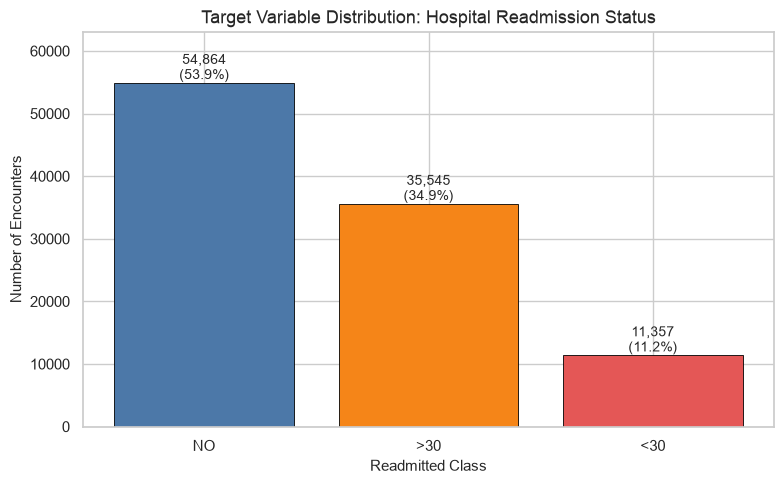

In [ ]:
# 1) Target variable distribution
target_counts = df["readmitted"].value_counts().reindex(READMIT_ORDER)
target_pct = (target_counts / target_counts.sum() * 100).round(1)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    target_counts.index.astype(str),
    target_counts.values,
    color=[READMIT_PALETTE[c] for c in target_counts.index],
    edgecolor="black",
    linewidth=0.6,
)
ax.set_title("Target Variable Distribution: Hospital Readmission Status")
ax.set_xlabel("Readmitted Class")
ax.set_ylabel("Number of Encounters")

for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{count:,}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

ax.set_ylim(0, target_counts.max() * 1.15)
plt.tight_layout()
plt.show()

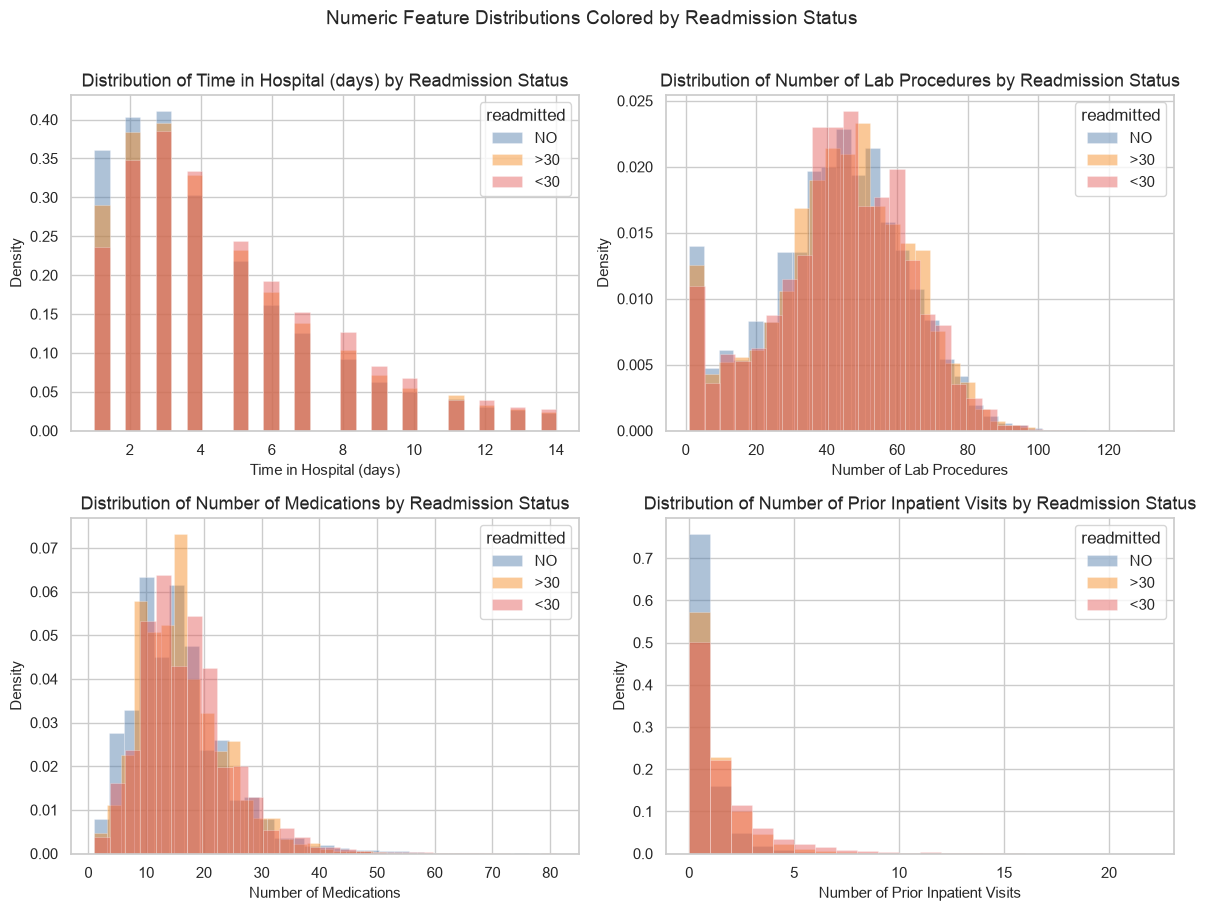

In [ ]:
# 2) Histograms of key numeric features, colored by readmission status
num_feats = ["time_in_hospital", "num_lab_procedures", "num_medications", "number_inpatient"]
labels = {
    "time_in_hospital": "Time in Hospital (days)",
    "num_lab_procedures": "Number of Lab Procedures",
    "num_medications": "Number of Medications",
    "number_inpatient": "Number of Prior Inpatient Visits",
}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for ax, col in zip(axes, num_feats):
    for cls in READMIT_ORDER:
        subset = df.loc[df["readmitted"] == cls, col]
        ax.hist(
            subset,
            bins=30 if col != "number_inpatient" else range(0, int(subset.max()) + 2),
            alpha=0.45,
            label=cls,
            color=READMIT_PALETTE[cls],
            edgecolor="white",
            linewidth=0.4,
            density=True,
        )
    ax.set_title(f"Distribution of {labels[col]} by Readmission Status")
    ax.set_xlabel(labels[col])
    ax.set_ylabel("Density")
    ax.legend(title="readmitted", loc="upper right")

fig.suptitle("Numeric Feature Distributions Colored by Readmission Status", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

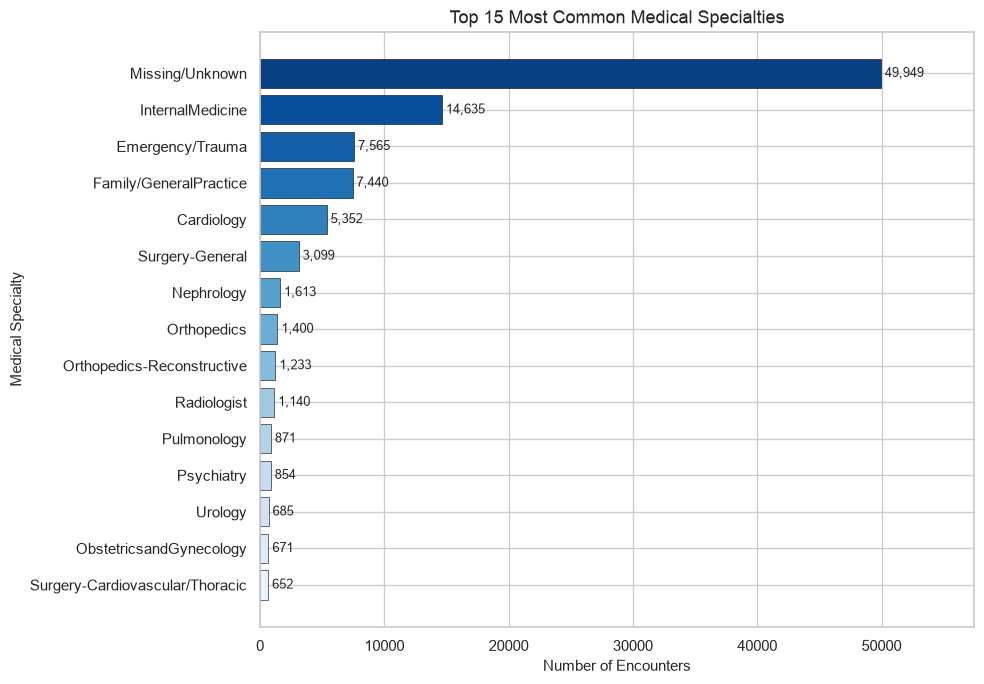

Note: Missing/Unknown includes original '?' values (49.1% of rows).
medical_specialty
Missing/Unknown           49949
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352


In [ ]:
# 3) Top 15 medical specialties (horizontal bar chart)
spec = df_miss["medical_specialty"].fillna("Missing/Unknown")
top15 = spec.value_counts().head(15).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = sns.color_palette("Blues", n_colors=len(top15))
bars = ax.barh(top15.index.astype(str), top15.values, color=colors, edgecolor="black", linewidth=0.4)

ax.set_title("Top 15 Most Common Medical Specialties")
ax.set_xlabel("Number of Encounters")
ax.set_ylabel("Medical Specialty")

for bar, val in zip(bars, top15.values):
    ax.text(val, bar.get_y() + bar.get_height() / 2, f" {val:,}", va="center", ha="left", fontsize=9)

# leave room for labels
ax.set_xlim(0, top15.max() * 1.15)
plt.tight_layout()
plt.show()

print("Note: Missing/Unknown includes original '?' values (49.1% of rows).")
print(top15.sort_values(ascending=False).head(5).to_string())

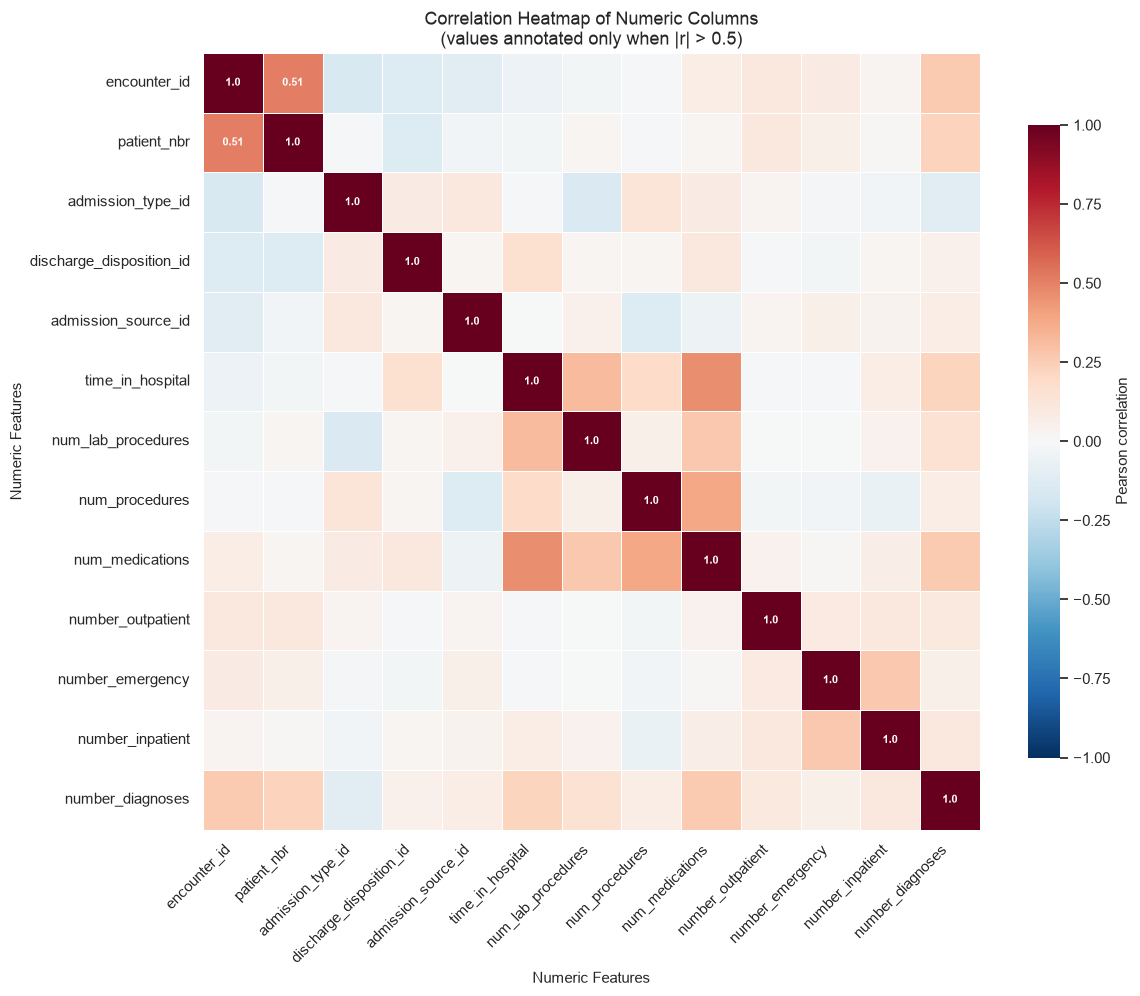

Pairs with |correlation| > 0.5:
   feature_1   feature_2  correlation
encounter_id patient_nbr     0.512028


In [ ]:
# 4) Correlation heatmap of all numeric columns (annotate |r| > 0.5)
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[num_cols].corr()

# Annotation matrix: show value only when abs(corr) > 0.5
annot = corr.where(corr.abs() > 0.5).round(2).astype(object)
annot = annot.where(annot.notna(), "")

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr,
    ax=ax,
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Pearson correlation", "shrink": 0.8},
    annot=annot,
    fmt="",
    annot_kws={"size": 8, "weight": "bold"},
)

ax.set_title("Correlation Heatmap of Numeric Columns\n(values annotated only when |r| > 0.5)")
ax.set_xlabel("Numeric Features")
ax.set_ylabel("Numeric Features")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print pairs with |r| > 0.5 (exclude self-corr)
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "correlation"]
strong = pairs.loc[pairs["correlation"].abs() > 0.5].sort_values("correlation", key=lambda s: s.abs(), ascending=False)
print("Pairs with |correlation| > 0.5:")
print(strong.to_string(index=False) if len(strong) else "None")

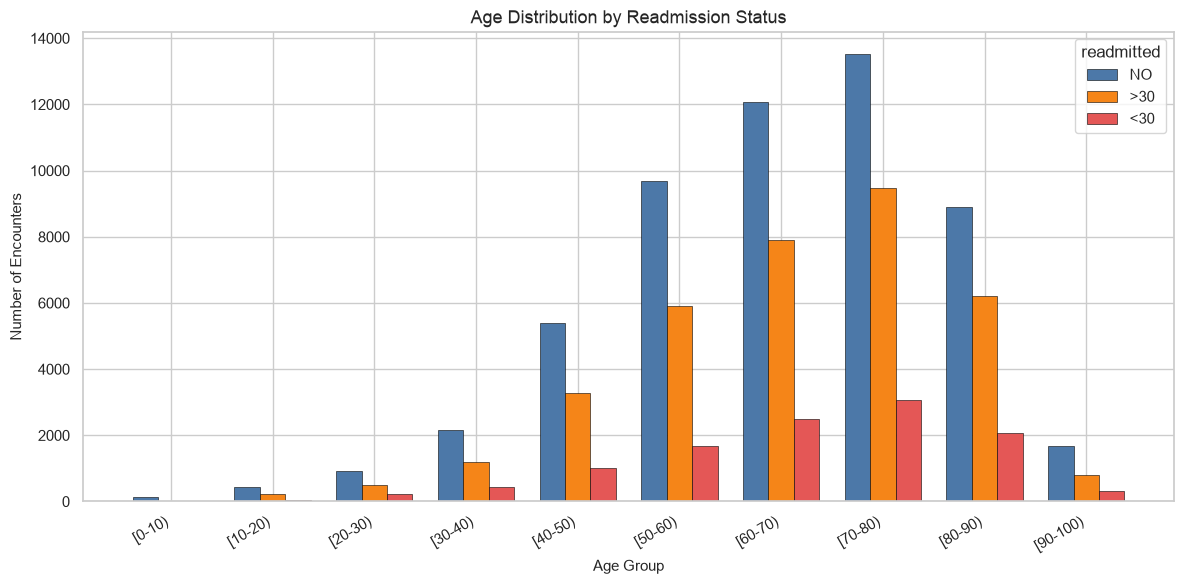

Readmission class % within each age group:
readmitted    NO   >30   <30
age                         
[0-10)      82.0  16.1   1.9
[10-20)     61.8  32.4   5.8
[20-30)     55.0  30.8  14.2
[30-40)     57.3  31.4  11.2
[40-50)     55.5  33.8  10.6
[50-60)     56.0  34.3   9.7
[60-70)     53.7  35.1  11.1
[70-80)     51.9  36.3  11.8
[80-90)     51.7  36.2  12.1
[90-100)    60.0  28.9  11.1


In [ ]:
# 5) Age distribution by readmission status (grouped bar chart)
age_order = [
    "[0-10)", "[10-20)", "[20-30)", "[30-40)", "[40-50)",
    "[50-60)", "[60-70)", "[70-80)", "[80-90)", "[90-100)",
]
# Keep only known bins (dataset uses these)
age_counts = (
    df.groupby(["age", "readmitted"], observed=False)
    .size()
    .unstack(fill_value=0)
    .reindex(index=age_order, columns=READMIT_ORDER)
)

x = np.arange(len(age_order))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))
for i, cls in enumerate(READMIT_ORDER):
    ax.bar(
        x + (i - 1) * width,
        age_counts[cls].values,
        width=width,
        label=cls,
        color=READMIT_PALETTE[cls],
        edgecolor="black",
        linewidth=0.4,
    )

ax.set_title("Age Distribution by Readmission Status")
ax.set_xlabel("Age Group")
ax.set_ylabel("Number of Encounters")
ax.set_xticks(x)
ax.set_xticklabels(age_order, rotation=30, ha="right")
ax.legend(title="readmitted")
plt.tight_layout()
plt.show()

# percentage within each age group for quick insight
age_pct = age_counts.div(age_counts.sum(axis=1), axis=0) * 100
print("Readmission class % within each age group:")
print(age_pct.round(1).to_string())

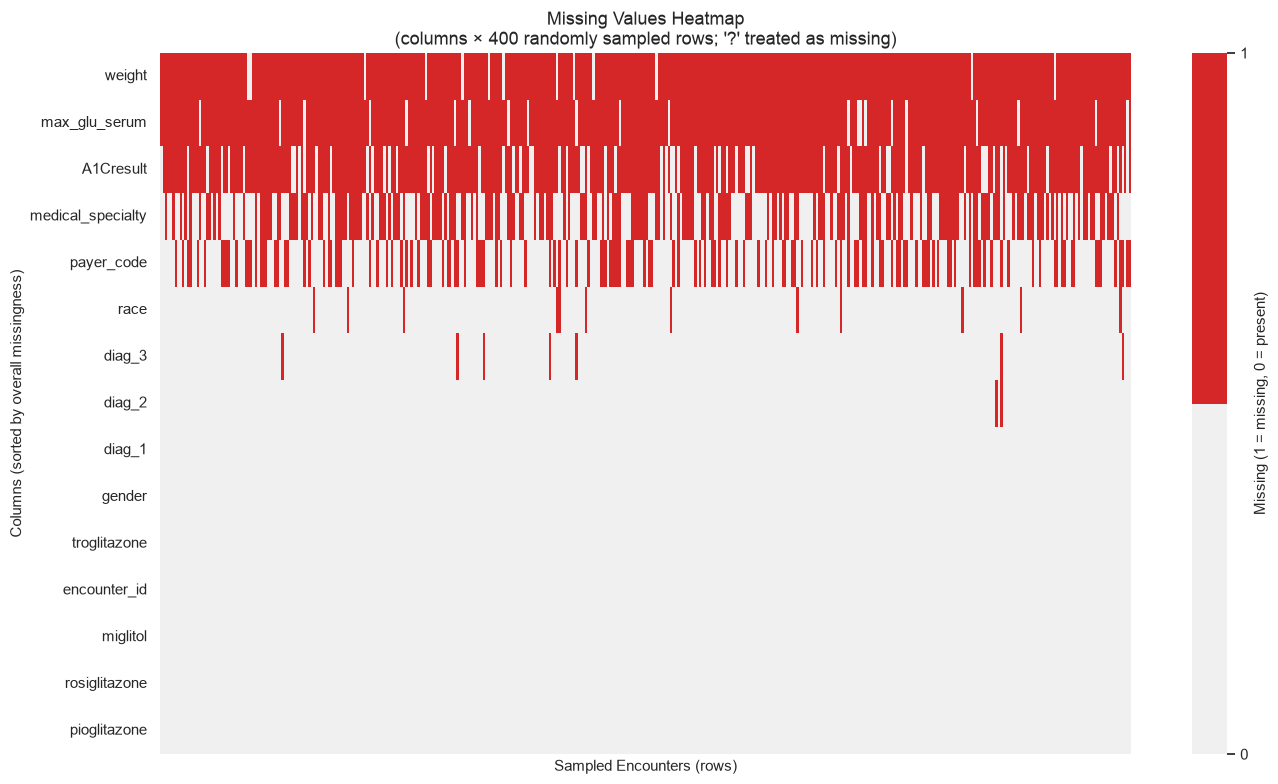

Overall missing % among plotted columns with any missing:
weight               96.86
max_glu_serum        94.75
A1Cresult            83.28
medical_specialty    49.08
payer_code           39.56
race                  2.23
diag_3                1.40
diag_2                0.35
diag_1                0.02
gender                0.00


In [ ]:
# 6) Missing values heatmap (columns vs sampled rows)
# Sort columns by missingness; sample rows for readability
miss_pct = df_miss.isna().mean().sort_values(ascending=False)
# Keep columns with any missing + a few complete ones so structure is visible
cols_with_missing = miss_pct[miss_pct > 0].index.tolist()
extra_complete = [c for c in miss_pct.index if c not in cols_with_missing][:5]
heat_cols = cols_with_missing + extra_complete

# Stratified-ish random sample of rows for visualization
rng = np.random.default_rng(42)
sample_n = 400
sample_idx = rng.choice(df_miss.index.to_numpy(), size=sample_n, replace=False)
miss_sample = df_miss.loc[sample_idx, heat_cols].isna()

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(
    miss_sample.T,  # columns on y, sampled rows on x
    ax=ax,
    cmap=sns.color_palette(["#f0f0f0", "#d62728"], as_cmap=True),
    cbar_kws={"label": "Missing (1 = missing, 0 = present)", "ticks": [0, 1]},
    yticklabels=True,
    xticklabels=False,
)

ax.set_title(f"Missing Values Heatmap\n(columns × {sample_n} randomly sampled rows; '?' treated as missing)")
ax.set_xlabel("Sampled Encounters (rows)")
ax.set_ylabel("Columns (sorted by overall missingness)")
plt.tight_layout()
plt.show()

print("Overall missing % among plotted columns with any missing:")
print((miss_pct[miss_pct > 0] * 100).round(2).to_string())

## 3 Most Interesting EDA Patterns

1. **Prior inpatient utilization separates readmission classes more clearly than length of stay or lab volume.**  
   Overlaid histograms show substantial overlap for `time_in_hospital`, `num_lab_procedures`, and `num_medications` across `NO` / `>30` / `<30`, but `number_inpatient` is much more right-skewed for readmitted patients—especially early (`<30`) readmissions. Recent hospitalization history looks like a stronger risk signal than current encounter intensity alone.

2. **Missingness is highly structured, not random noise.**  
   The missing-values heatmap (and overall rates) show near-total absence for `weight` (~97%), `max_glu_serum` (~95%), and `A1Cresult` (~83%), plus blocky missingness for `medical_specialty` (~49%) and `payer_code` (~40%). These appear systematic (rarely collected / coded as `?`) and should be handled with drop/indicator strategies rather than simple mean imputation. Specialty counts are also dominated by `Missing/Unknown`, then Internal Medicine, Emergency/Trauma, Family/General Practice, and Cardiology.

3. **Readmission risk is class-imbalanced and age-dependent; clinical numeric correlations are weak.**  
   Target bars show roughly 54% never readmitted, 35% after 30 days, and only 11% within 30 days. Age grouping indicates very low early readmission in children (`[0-10)` ~2% `<30`) and higher late/early readmission shares in older adult bands (peak volume around 70–80). The correlation heatmap finds almost no strong clinical numeric pairs—only `encounter_id`–`patient_nbr` exceeds |r| > 0.5—so multicollinearity among continuous clinical counts is limited, while ID columns remain leakage risks rather than useful features.

In [ ]:
# Inspect columns for encoding strategy
print("All columns:")
print(list(df.columns))
print("\nValue samples:")
for c in ["race", "gender", "age", "medical_specialty", "max_glu_serum", "A1Cresult",
          "change", "diabetesMed", "diag_1", "admission_type_id", "insulin", "metformin"]:
    print(f"\n{c}: {df[c].value_counts(dropna=False).head(8).to_dict()}")

med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
print("\nMedication unique values:")
for c in med_cols:
    if c in df.columns:
        print(c, sorted(df[c].dropna().unique().tolist()))

All columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'weight', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']

Value samples:

race: {'Caucasian': 76099, 'AfricanAmerican': 19210, '?': 2273, 'Hispanic': 2037, 'Other': 1506, 'Asian': 641}

gender: {'Female': 54708, 'Male': 47055,

## Data Cleaning Pipeline

Applied decisions for modeling-ready features:
1. Drop IDs, near-empty columns, and zero-variance meds.
2. Impute/group remaining missing/high-cardinality categoricals carefully.
3. Binarize early readmission target (`<30` = 1).
4. Encode diagnoses, medications, age, and remaining categoricals.

In [ ]:
# === Data Cleaning Pipeline ===
from pandas.api.types import is_numeric_dtype

def map_icd9_category(code):
    """Map ICD-9 diagnosis code to clinical category (Strack et al.-style groups)."""
    if pd.isna(code):
        return "missing"
    code = str(code).strip()
    if code in {"", "?", "nan", "None"}:
        return "missing"

    # External injury / supplemental codes often start with E/V
    upper = code.upper()
    if upper.startswith("E"):
        return "injury"
    if upper.startswith("V"):
        return "other"

    # keep leading digits (handles 250.xx, 4280, etc.)
    try:
        # strip non-numeric suffix after first non-digit except decimal
        num = float("".join(ch if (ch.isdigit() or ch == ".") else "" for ch in code) or "nan")
    except ValueError:
        return "other"

    if pd.isna(num):
        return "other"

    if 390 <= num <= 459 or num == 785:
        return "circulatory"
    if 460 <= num <= 519 or num == 786:
        return "respiratory"
    if 520 <= num <= 579 or num == 787:
        return "digestive"
    if abs(num - 250) < 1 or 250 <= num < 251:
        return "diabetes"
    if 800 <= num <= 999:
        return "injury"
    if 710 <= num <= 739:
        return "musculoskeletal"
    if 580 <= num <= 629 or num == 788:
        return "genitourinary"
    if 140 <= num <= 239:
        return "neoplasms"
    if 780 <= num <= 799 and num not in {785, 786, 787, 788}:
        return "other"
    if 240 <= num <= 279 and not (250 <= num < 251):
        return "other"  # endocrine/metabolic excl primary diabetes handled above
    return "other"


def age_to_midpoint(age_val):
    """Convert age bin like '[70-80)' to midpoint integer 75."""
    if pd.isna(age_val):
        return np.nan
    s = str(age_val).strip()
    # expected format [lo-hi)
    s = s.replace("[", "").replace("]", "").replace(")", "").replace("(", "")
    lo, hi = s.split("-")
    return int((int(lo) + int(hi)) / 2)


MED_ORDINAL = {"No": 0, "Steady": 1, "Down": 2, "Up": 3}
HIGH_CARD_THRESHOLD = 20

def build_clean_dataset(raw_df: pd.DataFrame) -> pd.DataFrame:
    df_c = raw_df.copy()

    # ---------- 1) DROPS ----------
    drop_cols = [
        "encounter_id", "patient_nbr",  # IDs
        "weight",                       # ~97% missing
        "payer_code",                   # ~40% missing
        "citoglipton", "examide",       # zero variance
    ]
    df_c = df_c.drop(columns=drop_cols)

    # ---------- 2) MISSING VALUES ----------
    # race: 'Unknown' (not mode — avoid demographic bias)
    df_c["race"] = df_c["race"].replace({"?": np.nan})
    df_c["race"] = df_c["race"].fillna("Unknown")

    # medical_specialty: missing/rare (<50) -> 'other/unknown'
    df_c["medical_specialty"] = df_c["medical_specialty"].replace({"?": np.nan})
    df_c["medical_specialty"] = df_c["medical_specialty"].fillna("other/unknown")
    spec_counts = df_c["medical_specialty"].value_counts()
    rare_specs = spec_counts[spec_counts < 50].index
    df_c.loc[df_c["medical_specialty"].isin(rare_specs), "medical_specialty"] = "other/unknown"
    # ensure the label used for unknown/rare is consistent
    df_c["medical_specialty"] = df_c["medical_specialty"].replace({"other/unknown": "other/unknown"})

    # diag_1/2/3: '?' -> NaN -> 'missing' (ICD mapping will also treat missing)
    for dcol in ["diag_1", "diag_2", "diag_3"]:
        df_c[dcol] = df_c[dcol].replace({"?": np.nan})
        df_c[dcol] = df_c[dcol].fillna("missing")

    # other known placeholder incompleteness
    df_c["gender"] = df_c["gender"].replace({"Unknown/Invalid": "Unknown"})
    # max_glu_serum / A1Cresult are mostly missing but not dropped per decisions; treat NaN as explicit category
    for col in ["max_glu_serum", "A1Cresult"]:
        if col in df_c.columns:
            df_c[col] = df_c[col].fillna("None")  # common in this dataset semantics: test not taken

    # ---------- 3) TARGET BINARY ----------
    # '<30' -> 1, else -> 0
    df_c["readmitted"] = (df_c["readmitted"] == "<30").astype(int)

    # ---------- 4) ENCODE ----------
    # Diagnosis ICD-9 groups
    for dcol in ["diag_1", "diag_2", "diag_3"]:
        df_c[dcol] = df_c[dcol].map(map_icd9_category)

    # Medication ordinal encoding (remaining med columns still present)
    med_cols = [
        "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
        "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
        "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
        "insulin", "glyburide-metformin", "glipizide-metformin",
        "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
    ]
    med_cols = [c for c in med_cols if c in df_c.columns]
    for col in med_cols:
        unknown_levels = set(df_c[col].dropna().unique()) - set(MED_ORDINAL)
        if unknown_levels:
            raise ValueError(f"Unexpected medication levels in {col}: {unknown_levels}")
        df_c[col] = df_c[col].map(MED_ORDINAL).astype(int)

    # Age bins -> midpoint integers
    df_c["age"] = df_c["age"].map(age_to_midpoint).astype(int)

    # Integer-coded categoricals should be treated as categorical for encoding
    code_like_cols = ["admission_type_id", "discharge_disposition_id", "admission_source_id"]
    for col in code_like_cols:
        if col in df_c.columns:
            df_c[col] = df_c[col].astype(str)

    # Separate remaining feature columns by cardinality strategy
    target_col = "readmitted"
    feature_cols = [c for c in df_c.columns if c != target_col]

    # Already numeric (counts + ordinal meds + age)
    numeric_cols = [c for c in feature_cols if is_numeric_dtype(df_c[c])]
    categorical_cols = [c for c in feature_cols if c not in numeric_cols]

    # Split categoricals into low/high cardinality
    low_card_cols, high_card_cols = [], []
    for col in categorical_cols:
        nunique = df_c[col].nunique(dropna=False)
        if nunique > HIGH_CARD_THRESHOLD:
            high_card_cols.append(col)
        else:
            low_card_cols.append(col)

    # Frequency encode high-cardinality categoricals
    for col in high_card_cols:
        freq = df_c[col].value_counts(normalize=True)
        df_c[f"{col}_freq"] = df_c[col].map(freq).astype(float)
        df_c = df_c.drop(columns=[col])

    # One-hot encode low-cardinality categoricals
    if low_card_cols:
        df_c = pd.get_dummies(df_c, columns=low_card_cols, drop_first=False, dtype=int)

    # ---------- Final missing check hygiene ----------
    # Any residual NaNs (should be none for pipeline path)
    if df_c.isna().any().any():
        # last-resort: only if unexpected residual object empties
        for col in df_c.columns:
            if df_c[col].isna().any():
                if is_numeric_dtype(df_c[col]):
                    df_c[col] = df_c[col].fillna(df_c[col].median())
                else:
                    df_c[col] = df_c[col].fillna("missing")

    return df_c, {
        "dropped": drop_cols,
        "med_cols_encoded": med_cols,
        "low_card_onehot": low_card_cols,
        "high_card_freq": high_card_cols,
        "numeric_passthrough": numeric_cols,
    }


df_clean, clean_meta = build_clean_dataset(df)

print("=== CLEANING COMPLETE ===")
print(f"Final shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"Final dtypes breakdown:\n{df_clean.dtypes.value_counts()}")
print(f"\nMissing values remaining: {int(df_clean.isna().sum().sum())}")
print(f"Any missing? {df_clean.isna().any().any()}")

print("\nTarget distribution (binary readmitted <30):")
print(df_clean["readmitted"].value_counts(normalize=False).rename("count").to_frame().assign(
    pct=lambda x: (x["count"] / x["count"].sum() * 100).round(2)
))

print("\nEncoding metadata:")
for k, v in clean_meta.items():
    print(f"  {k}: {v}")

print("\nSample of cleaned columns:")
print(list(df_clean.columns)[:40], "...")
print(f"Total columns: {len(df_clean.columns)}")
df_clean.head(3)

=== CLEANING COMPLETE ===
Final shape: 101,766 rows × 106 columns
Final dtypes breakdown:
int64      104
float64      2
Name: count, dtype: int64

Missing values remaining: 0
Any missing? False

Target distribution (binary readmitted <30):
            count    pct
readmitted              
0           90409  88.84
1           11357  11.16

Encoding metadata:
  dropped: ['encounter_id', 'patient_nbr', 'weight', 'payer_code', 'citoglipton', 'examide']
  med_cols_encoded: ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
  low_card_onehot: ['race', 'gender', 'admission_type_id', 'admission_source_id', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'change', 'diabetesMed']


,age,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses,metformin,...,max_glu_serum_None,max_glu_serum_Norm,A1Cresult_>7,A1Cresult_>8,A1Cresult_None,A1Cresult_Norm,change_Ch,change_No,diabetesMed_No,diabetesMed_Yes
0,5,1,41,0,1,0,0,0,1,0,...,1,0,0,0,1,0,0,1,1,0
1,15,3,59,0,18,0,0,0,9,0,...,1,0,0,0,1,0,1,0,0,1
2,25,2,11,5,13,2,0,1,6,0,...,1,0,0,0,1,0,0,1,0,1


In [ ]:
# Final validation summary for cleaned dataset
print("=== FINAL VALIDATION ===")
print(f"Shape: {df_clean.shape}")
print(f"Dtypes:\n{df_clean.dtypes.value_counts().to_string()}")
print(f"Missing values (total): {int(df_clean.isna().sum().sum())}")
print(f"Missing values per column > 0: {(df_clean.isna().sum() > 0).sum()}")

print("\nTarget 'readmitted' (1 = <30 days):")
vc = df_clean["readmitted"].value_counts().sort_index()
print(pd.DataFrame({"count": vc, "pct": (vc / len(df_clean) * 100).round(2)}).to_string())

print("\nAge midpoints present:", sorted(df_clean["age"].unique().tolist()))
print("Medication ordinal sample ranges:")
for c in ["metformin", "insulin", "glipizide"]:
    print(f"  {c}: min={df_clean[c].min()}, max={df_clean[c].max()}, uniques={sorted(df_clean[c].unique().tolist())}")

print("\nFrequency-encoded cols:")
for c in [c for c in df_clean.columns if c.endswith("_freq")]:
    print(f"  {c}: [{df_clean[c].min():.4f}, {df_clean[c].max():.4f}]")

print("\nOne-hot column groups (counts):")
for prefix in ["race_", "gender_", "diag_1_", "diag_2_", "diag_3_", "admission_type_id_",
               "admission_source_id_", "max_glu_serum_", "A1Cresult_", "change_", "diabetesMed_"]:
    n = sum(c.startswith(prefix) for c in df_clean.columns)
    if n:
        print(f"  {prefix}* -> {n} columns")

assert df_clean.isna().sum().sum() == 0, "Missing values remain!"
assert set(df_clean.dtypes.astype(str).unique()) <= {"int64", "float64", "int32", "float32", "uint8", "bool"}
assert df_clean["readmitted"].isin([0, 1]).all()
print("\nAll validation checks passed.")

=== FINAL VALIDATION ===
Shape: (101766, 106)
Dtypes:
int64      104
float64      2
Missing values (total): 0
Missing values per column > 0: 0

Target 'readmitted' (1 = <30 days):
            count    pct
readmitted              
0           90409  88.84
1           11357  11.16

Age midpoints present: [5, 15, 25, 35, 45, 55, 65, 75, 85, 95]
Medication ordinal sample ranges:
  metformin: min=0, max=3, uniques=[0, 1, 2, 3]
  insulin: min=0, max=3, uniques=[0, 1, 2, 3]
  glipizide: min=0, max=3, uniques=[0, 1, 2, 3]

Frequency-encoded cols:
  discharge_disposition_id_freq: [0.0000, 0.5919]
  medical_specialty_freq: [0.0005, 0.4956]

One-hot column groups (counts):
  race_* -> 6 columns
  gender_* -> 3 columns
  diag_1_* -> 9 columns
  diag_2_* -> 9 columns
  diag_3_* -> 9 columns
  admission_type_id_* -> 8 columns
  admission_source_id_* -> 17 columns
  max_glu_serum_* -> 4 columns
  A1Cresult_* -> 4 columns
  change_* -> 2 columns
  diabetesMed_* -> 2 columns

All validation checks pass

## Cleaning Pipeline — Key Judgment Calls

**Final dataset:** `df_clean` → **101,766 rows × 106 columns**, all numeric (`int64`/`float64`), **0 missing values**.  
**Target:** binary early readmission (`readmitted = 1` if `<30`, else `0`) → **11.16% positive**.

### Why these choices
1. **Dropped IDs / sparse / constant columns**  
   - `encounter_id`: unique per row → pure identifier leakage risk.  
   - `patient_nbr`: entity key (useful for split grouping later, not as a feature).  
   - `weight` (~97% missing) and `payer_code` (~40% missing): too sparse relative to signal cost; would mostly become “missingness” features.  
   - `examide` / `citoglipton`: constant `No` → zero variance, no predictive value.

2. **Race imputed as `Unknown`, not mode**  
   Mode imputation would collapse missing race into `Caucasian` (majority), biasing a protected attribute. Explicit `Unknown` preserves uncertainty and avoids injecting the majority demographic.

3. **Specialty collapse:** missing + rare (`n < 50`) → `other/unknown`  
   Admitted specialties are long-tailed; rare labels overfit and explode one-hot width. Grouping rare + `?` keeps frequent specialties meaningful while bounding cardinality, then **frequency encode** specialty (still high-cardinality after grouping relative policy variants). Discharge disposition stayed high-cardinality → **frequency encode**; admission type/source were one-hotable after casting to categorical codes.

4. **Diagnostics + ICD grouping before encoding**  
   Raw ICD-9 strings (`diag_1/2/3`) are 700+ levels. Mapping into clinical groups (circulatory, respiratory, diabetes, digestive, injury, musculoskeletal, genitourinary, neoplasms, other, missing) follows common readmission literature and turns them into low-cardinality one-hots. Missing/`?` kept as explicit **`missing`** (not mode) so absence remains informative.

5. **Medication ordinal map: No=0, Steady=1, Down=2, Up=3**  
   Encodes dose-change directionality without treating labels as unordered. Note: this imposes a numeric scale that is **not strictly interval** (Down vs Up severity may not be linear); keep in mind for model interpretation.

6. **Age midpoints (5, 15, …, 95)**  
   Retains ordinal/interval structure of 10-year bins and works with tree and linear models without dummy inflation.

7. **Blanket handling left for non-dropped sparse labs**  
   `max_glu_serum` and `A1Cresult` were **not** in the drop list; absent tests filled as category **`None`** then one-hot encoded, which is preferable to inventing lab values.

8. **Encoding policy**  
   - Low-cardinality categoricals (`nunique ≤ 20`): **one-hot**.  
   - High-cardinality: **frequency encoding** (`*_freq`).  
   - ID-like admission/disposition/source codes treated as **categorical**, not continuous integers.

### Resulting risks still to remember at modeling time
- Strong class imbalance (~11% early readmission).  
- Frequency encodings are **train-distribution dependent** → should be fit on train folds only in MLCV to avoid leakage.  
- Patient-level dependence remains (same patient, multiple encounters) even after dropping `patient_nbr` — use grouped splits if leakage control matters.

In [ ]:
# Confirm base columns available for feature engineering
needed = [
    "num_medications", "num_procedures", "num_lab_procedures",
    "number_emergency", "number_inpatient", "number_outpatient",
    "number_diagnoses", "time_in_hospital", "readmitted",
]
print("Base columns present:", {c: c in df_clean.columns for c in needed})

med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
med_cols = [c for c in med_cols if c in df_clean.columns]
print(f"Medication cols available ({len(med_cols)}):", med_cols)
print("diag one-hot counts:", sum(c.startswith("diag_") for c in df_clean.columns))
print("Current shape:", df_clean.shape)
# medication ordinal: No=0, Steady=1, Down=2, Up=3  → change is Down/Up (2 or 3)
print({c: sorted(df_clean[c].unique().tolist()) for c in med_cols[:3]})
print(df_clean[["number_diagnoses"] + [c for c in df_clean.columns if c.startswith("diag_1_")]].head(2))

Base columns present: {'num_medications': True, 'num_procedures': True, 'num_lab_procedures': True, 'number_emergency': True, 'number_inpatient': True, 'number_outpatient': True, 'number_diagnoses': True, 'time_in_hospital': True, 'readmitted': True}
Medication cols available (21): ['metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']
diag one-hot counts: 27
Current shape: (101766, 106)
{'metformin': [0, 1, 2, 3], 'repaglinide': [0, 1, 2, 3], 'nateglinide': [0, 1, 2, 3]}
   number_diagnoses  diag_1_circulatory  diag_1_diabetes  diag_1_digestive  \
0                 1                   0                1                 0   
1                 9                   0                0      

In [ ]:
# === Feature Engineering ===
df_fe = df_clean.copy()

med_cols = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "insulin", "glyburide-metformin", "glipizide-metformin",
    "glimepiride-pioglitazone", "metformin-rosiglitazone", "metformin-pioglitazone",
]
med_cols = [c for c in med_cols if c in df_fe.columns]

# ---------- 1) INTERACTIONS ----------
# Total medical burden: meds + procedures + labs
df_fe["total_medical_burden"] = (
    df_fe["num_medications"] + df_fe["num_procedures"] + df_fe["num_lab_procedures"]
)

# Medication-to-procedure ratio (eps avoids div-by-zero)
df_fe["med_to_procedure_ratio"] = df_fe["num_medications"] / (df_fe["num_procedures"] + 1)

# Emergency-to-inpatient ratio
df_fe["emergency_to_inpatient_ratio"] = df_fe["number_emergency"] / (df_fe["number_inpatient"] + 1)

# ---------- 2) AGGREGATIONS ----------
# Total diagnoses present:
# Prefer counting non-missing primary/secondary diagnosis slots if missing dummies exist;
# else fall back to number_diagnoses already recorded by the hospital.
diag_missing_cols = [c for c in ["diag_1_missing", "diag_2_missing", "diag_3_missing"] if c in df_fe.columns]
if len(diag_missing_cols) == 3:
    df_fe["total_diagnoses_present"] = 3 - df_fe[diag_missing_cols].sum(axis=1)
else:
    # number_diagnoses is the clinical count of diagnoses on the encounter
    df_fe["total_diagnoses_present"] = df_fe["number_diagnoses"]

# Medication changes: ordinal encoding uses No=0, Steady=1, Down=2, Up=3
# A "change" is Down or Up (values >= 2)
med_change_matrix = (df_fe[med_cols] >= 2)
df_fe["n_medication_changes"] = med_change_matrix.sum(axis=1).astype(int)
df_fe["any_medication_change"] = (df_fe["n_medication_changes"] > 0).astype(int)

# ---------- 3) CLINICAL INDICATORS ----------
# High utilizer: inpatient >= 2 OR emergency >= 2
df_fe["high_utilizer"] = (
    (df_fe["number_inpatient"] >= 2) | (df_fe["number_emergency"] >= 2)
).astype(int)

# Complex stay: hospital days >= 7 AND procedures >= 3
df_fe["complex_stay"] = (
    (df_fe["time_in_hospital"] >= 7) & (df_fe["num_procedures"] >= 3)
).astype(int)

# Polypharmacy: medications >= 15
df_fe["polypharmacy"] = (df_fe["num_medications"] >= 15).astype(int)

# ---------- 4) STATISTICAL: z-scores + outlier flags (|z| > 2) ----------
visit_cols = {
    "number_inpatient": "inpatient",
    "number_emergency": "emergency",
    "number_outpatient": "outpatient",
}
for raw_col, short in visit_cols.items():
    mu = df_fe[raw_col].mean()
    sigma = df_fe[raw_col].std(ddof=0)
    zcol = f"{short}_zscore"
    ocol = f"{short}_outlier"
    df_fe[zcol] = (df_fe[raw_col] - mu) / sigma if sigma > 0 else 0.0
    df_fe[ocol] = (df_fe[zcol].abs() > 2).astype(int)

# Track newly created feature names
new_features = [
    # interactions
    "total_medical_burden",
    "med_to_procedure_ratio",
    "emergency_to_inpatient_ratio",
    # aggregations
    "total_diagnoses_present",
    "n_medication_changes",
    "any_medication_change",
    # clinical indicators
    "high_utilizer",
    "complex_stay",
    "polypharmacy",
    # statistical
    "inpatient_zscore",
    "inpatient_outlier",
    "emergency_zscore",
    "emergency_outlier",
    "outpatient_zscore",
    "outpatient_outlier",
]

print("=== ENGINEERED FEATURES CREATED ===")
print(f"New features ({len(new_features)}):")
for f in new_features:
    print(f"  - {f}")

print("\nSimple descriptive snapshot of new features:")
print(df_fe[new_features].describe().T[["mean", "std", "min", "50%", "max"]].round(3).to_string())

print("\nBinary flag rates:")
for f in ["any_medication_change", "high_utilizer", "complex_stay", "polypharmacy",
          "inpatient_outlier", "emergency_outlier", "outpatient_outlier"]:
    print(f"  {f}: {df_fe[f].mean()*100:.2f}%")

print(f"\nUpdated dataset shape: {df_fe.shape[0]:,} rows × {df_fe.shape[1]} columns")
print(f"(was {df_clean.shape[1]} columns before engineering → +{df_fe.shape[1] - df_clean.shape[1]})")

=== ENGINEERED FEATURES CREATED ===
New features (15):
  - total_medical_burden
  - med_to_procedure_ratio
  - emergency_to_inpatient_ratio
  - total_diagnoses_present
  - n_medication_changes
  - any_medication_change
  - high_utilizer
  - complex_stay
  - polypharmacy
  - inpatient_zscore
  - inpatient_outlier
  - emergency_zscore
  - emergency_outlier
  - outpatient_zscore
  - outpatient_outlier

Simple descriptive snapshot of new features:
                                mean     std    min     50%      max
total_medical_burden          60.457  23.588  2.000  61.000  179.000
med_to_procedure_ratio         9.313   5.813  0.200   8.000   50.000
emergency_to_inpatient_ratio   0.105   0.441  0.000   0.000   37.000
total_diagnoses_present        7.423   1.934  1.000   8.000   16.000
n_medication_changes           0.287   0.488  0.000   0.000    4.000
any_medication_change          0.272   0.445  0.000   0.000    1.000
high_utilizer                  0.162   0.369  0.000   0.000    1.000


In [ ]:
# === New feature ↔ target correlations + multicollinearity check ===
target = "readmitted"

# 1) Correlation with target (sorted by absolute value; show signed corr too)
corr_target = df_fe[new_features + [target]].corr(numeric_only=True)[target].drop(target)
corr_tbl = (
    corr_target.to_frame("corr_with_readmitted")
    .assign(abs_corr=lambda x: x["corr_with_readmitted"].abs())
    .sort_values("abs_corr", ascending=False)
)
print("=== Correlation of NEW features with target (sorted by |r|) ===")
print(corr_tbl.round(4).to_string())

# 2) Multicollinearity among new features + closely related base inputs used to build them
multi_check_cols = new_features + [
    "num_medications", "num_procedures", "num_lab_procedures",
    "number_inpatient", "number_emergency", "number_outpatient",
    "number_diagnoses", "time_in_hospital",
]
multi_check_cols = list(dict.fromkeys([c for c in multi_check_cols if c in df_fe.columns]))

corr_mat = df_fe[multi_check_cols].corr(numeric_only=True)
pairs = (
    corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)
pairs.columns = ["feature_1", "feature_2", "correlation"]
high_mc = pairs.loc[pairs["correlation"].abs() >= 0.8].sort_values(
    "correlation", key=lambda s: s.abs(), ascending=False
)

print("\n=== Multicollinearity check: pairs with |r| ≥ 0.8 ===")
if len(high_mc):
    print(high_mc.round(4).to_string(index=False))
    print(f"\nFLAGGED: {len(high_mc)} highly correlated pair(s).")
else:
    print("None — no pairs with |r| ≥ 0.8 among engineered/related features.")

# Optionally highlight only pairs that include at least one new feature
high_mc_new = high_mc[
    high_mc["feature_1"].isin(new_features) | high_mc["feature_2"].isin(new_features)
]
print(f"Pairs involving ≥1 new feature: {len(high_mc_new)}")

# 3) Updated shape + missing check
print("\n=== Updated dataset ===")
print(f"Shape: {df_fe.shape[0]:,} rows × {df_fe.shape[1]} columns")
print(f"New features added: {len(new_features)}")
print(f"Missing values in new features: {int(df_fe[new_features].isna().sum().sum())}")
print(f"Missing values overall: {int(df_fe.isna().sum().sum())}")

# Keep df_clean progressing? Prefer modeling frame to be df_fe going forward
# (do not overwrite df_clean so both remain available)
print("\nFrames available: df_clean (pre-FE), df_fe (with engineered features).")

=== Correlation of NEW features with target (sorted by |r|) ===
                              corr_with_readmitted  abs_corr
inpatient_zscore                            0.1651    0.1651
high_utilizer                               0.1319    0.1319
inpatient_outlier                           0.1195    0.1195
emergency_zscore                            0.0607    0.0607
emergency_outlier                           0.0564    0.0564
total_diagnoses_present                     0.0495    0.0495
polypharmacy                                0.0402    0.0402
med_to_procedure_ratio                      0.0399    0.0399
any_medication_change                       0.0370    0.0370
n_medication_changes                        0.0349    0.0349
total_medical_burden                        0.0293    0.0293
emergency_to_inpatient_ratio                0.0281    0.0281
complex_stay                                0.0197    0.0197
outpatient_zscore                           0.0189    0.0189
outpatient_outlier   

In [ ]:
# Check available packages and alignment of patient_nbr with engineered frame
import importlib.util

def has_mod(name):
    return importlib.util.find_spec(name) is not None

print("sklearn:", has_mod("sklearn"))
print("xgboost:", has_mod("xgboost"))
print("lightgbm:", has_mod("lightgbm"))
print("df_fe shape:", df_fe.shape)
print("df shape:", df.shape)
print("Index aligned?", df_fe.index.equals(df.index))
print("patient_nbr nunique:", df["patient_nbr"].nunique())
print("readmitted rate:", df_fe["readmitted"].mean())

sklearn: False
xgboost: False
lightgbm: False
df_fe shape: (101766, 121)
df shape: (101766, 50)
Index aligned? True
patient_nbr nunique: 71518
readmitted rate: 0.11159915885462728


In [ ]:
# === MODELING SETUP: group-aware 80/20 split + holdout isolation ===
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
)

import xgboost as xgb
import lightgbm as lgb

# Groups for leakage control (must not appear in features)
groups_all = df["patient_nbr"].to_numpy()
y_all = df_fe["readmitted"].to_numpy().astype(int)
X_all = df_fe.drop(columns=["readmitted"]).copy()

# Ensure purely numeric matrix
non_num = X_all.select_dtypes(exclude=[np.number]).columns.tolist()
if non_num:
    raise ValueError(f"Non-numeric columns remaining: {non_num}")

feature_names = X_all.columns.tolist()
X_all_np = X_all.to_numpy(dtype=float)

# 80/20 stratified group-aware split (no patient in both sets)
gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss.split(X_all_np, y_all, groups_all))

X_train = X_all_np[train_idx]
X_test = X_all_np[test_idx]          # HOLD OUT — do not use until final evaluation
y_train = y_all[train_idx]
y_test = y_all[test_idx]             # HOLD OUT
groups_train = groups_all[train_idx]
groups_test = groups_all[test_idx]
train_patient = set(groups_train)
test_patient = set(groups_test)

# Verify patient disjointness
overlap = train_patient & test_patient
print("=== GROUP-AWARE SPLIT ===")
print(f"Train: {len(train_idx):,} rows | {len(train_patient):,} patients | pos rate={y_train.mean():.4f}")
print(f"Test : {len(test_idx):,} rows | {len(test_patient):,} patients | pos rate={y_test.mean():.4f}")
print(f"Patient overlap train∩test: {len(overlap)} (must be 0)")
assert len(overlap) == 0, "Patient leakage across split!"

# Persist holdout explicitly
holdout = {
    "X_test": X_test,
    "y_test": y_test,
    "groups_test": groups_test,
    "test_idx": test_idx,
    "feature_names": feature_names,
}
print("Test set saved in `holdout` and will not be used in baseline CV.")

# Secondary check of near-stratification quality
print(f"Overall pos rate: {y_all.mean():.4f}")
print(f"Train/Test size split: {len(train_idx)/len(y_all):.1%} / {len(test_idx)/len(y_all):.1%}")
print(f"Features: {len(feature_names)}")

=== GROUP-AWARE SPLIT ===
Train: 81,613 rows | 57,214 patients | pos rate=0.1128
Test : 20,153 rows | 14,304 patients | pos rate=0.1067
Patient overlap train∩test: 0 (must be 0)
Test set saved in `holdout` and will not be used in baseline CV.
Overall pos rate: 0.1116
Train/Test size split: 80.2% / 19.8%
Features: 120


In [ ]:
# === BASELINE MODELING: 5-fold StratifiedGroupKFold CV on TRAINING only ===

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Models (pipelines where scaling helps)
scale_pos = (y_train == 0).sum() / max((y_train == 1).sum(), 1)

models = {
    "Dummy (majority)": DummyClassifier(strategy="most_frequent", random_state=42),
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            solver="lbfgs",
            random_state=42,
            n_jobs=-1,
        )),
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=500,
        class_weight="balanced_subsample",
        random_state=42,
        n_jobs=-1,
    ),
    "XGBoost": xgb.XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        objective="binary:logistic",
        eval_metric="aucpr",
        tree_method="hist",
        scale_pos_weight=scale_pos,
        random_state=42,
        n_jobs=-1,
        verbosity=0,
    ),
    "LightGBM": lgb.LGBMClassifier(
        n_estimators=200,
        learning_rate=0.05,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary",
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    ),
}


def get_proba(model, X):
    """Positive-class probability or score; Dummy handled for multi-class we collapse."""
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)
        # majority dummy returns a single column if only one class learned
        if proba.ndim == 1:
            return proba
        if proba.shape[1] == 1:
            # most_frequent class only — if that class is 0, scores are all 0
            classes = getattr(model, "classes_", None)
            if classes is not None and len(classes) == 1:
                return np.full(len(X), float(classes[0]))
            return proba[:, 0]
        # use column for positive class=1 if available
        classes = list(getattr(model, "classes_", [0, 1]))
        if 1 in classes:
            return proba[:, classes.index(1)]
        return proba[:, -1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X)
    # fall back to hard labels
    return model.predict(X).astype(float)


records = []
# store OOF predictions for global ROC/PR curves on training via CV
oof_scores = {name: np.zeros(len(y_train), dtype=float) for name in models}
oof_pred = {name: np.zeros(len(y_train), dtype=int) for name in models}
fold_times = {name: [] for name in models}
fold_metrics = {name: [] for name in models}

print(f"Running 5-fold StratifiedGroupKFold on train ({len(y_train):,} rows)...\n")

for fold, (tr_i, va_i) in enumerate(cv.split(X_train, y_train, groups_train), start=1):
    X_tr, X_va = X_train[tr_i], X_train[va_i]
    y_tr, y_va = y_train[tr_i], y_train[va_i]
    # enforce fold group disjointness
    assert len(set(groups_train[tr_i]) & set(groups_train[va_i])) == 0

    print(f"Fold {fold}/5 | train={len(tr_i):,} valid={len(va_i):,} pos={y_va.mean():.3f}")

    for name, model in models.items():
        # fresh clone each fold
        if name == "Dummy (majority)":
            m = DummyClassifier(strategy="most_frequent", random_state=42)
        elif name == "Logistic Regression":
            m = Pipeline([
                ("scaler", StandardScaler()),
                ("clf", LogisticRegression(
                    max_iter=2000, class_weight="balanced", solver="lbfgs",
                    random_state=42, n_jobs=-1,
                )),
            ])
        elif name == "Random Forest":
            m = RandomForestClassifier(
                n_estimators=500, class_weight="balanced_subsample",
                random_state=42, n_jobs=-1,
            )
        elif name == "XGBoost":
            # scale_pos_weight by fold for better balance reflection
            spw = (y_tr == 0).sum() / max((y_tr == 1).sum(), 1)
            m = xgb.XGBClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=6,
                subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
                objective="binary:logistic", eval_metric="aucpr",
                tree_method="hist", scale_pos_weight=spw,
                random_state=42, n_jobs=-1, verbosity=0,
            )
        else:  # LightGBM
            m = lgb.LGBMClassifier(
                n_estimators=200, learning_rate=0.05, num_leaves=31,
                subsample=0.8, colsample_bytree=0.8, objective="binary",
                class_weight="balanced", random_state=42, n_jobs=-1, verbose=-1,
            )

        t0 = time.perf_counter()
        m.fit(X_tr, y_tr)
        train_time = time.perf_counter() - t0
        fold_times[name].append(train_time)

        scores = get_proba(m, X_va)
        preds = (scores >= 0.5).astype(int) if scores.min() >= 0 and scores.max() <= 1 else (scores >= 0).astype(int)
        # For dummy most_frequent, scores may be constant 0; keep hard predictions
        hard = m.predict(X_va).astype(int)

        # metrics — if no positives in fold (shouldn't happen with stratification), guard AUC
        try:
            auc = roc_auc_score(y_va, scores)
        except ValueError:
            auc = np.nan
        try:
            pr_auc = average_precision_score(y_va, scores)
        except ValueError:
            pr_auc = np.nan

        prec = precision_score(y_va, hard, zero_division=0)
        rec = recall_score(y_va, hard, zero_division=0)
        f1 = f1_score(y_va, hard, zero_division=0)

        fold_metrics[name].append({
            "fold": fold,
            "auc_roc": auc,
            "pr_auc": pr_auc,
            "precision": prec,
            "recall": rec,
            "f1": f1,
            "train_time_sec": train_time,
        })

        oof_scores[name][va_i] = scores
        oof_pred[name][va_i] = hard

        print(f"  {name:20s}  PR-AUC={pr_auc:.4f}  AUC={auc:.4f}  F1={f1:.4f}  time={train_time:.2f}s")

# Aggregate comparison table
rows = []
for name in models:
    fm = pd.DataFrame(fold_metrics[name])
    rows.append({
        "model": name,
        "PR-AUC": fm["pr_auc"].mean(),
        "PR-AUC_std": fm["pr_auc"].std(),
        "AUC-ROC": fm["auc_roc"].mean(),
        "AUC-ROC_std": fm["auc_roc"].std(),
        "Precision": fm["precision"].mean(),
        "Recall": fm["recall"].mean(),
        "F1": fm["f1"].mean(),
        "Train_time_sec_mean": fm["train_time_sec"].mean(),
        "Train_time_sec_total_5fold": fm["train_time_sec"].sum(),
    })

comparison = (
    pd.DataFrame(rows)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)
comparison_display = comparison.copy()
for c in ["PR-AUC", "PR-AUC_std", "AUC-ROC", "AUC-ROC_std", "Precision", "Recall", "F1"]:
    comparison_display[c] = comparison_display[c].map(lambda v: f"{v:.4f}")
for c in ["Train_time_sec_mean", "Train_time_sec_total_5fold"]:
    comparison_display[c] = comparison_display[c].map(lambda v: f"{v:.2f}")

print("\n=== BASELINE COMPARISON (5-fold StratifiedGroup CV, sorted by PR-AUC) ===")
print(comparison_display.to_string(index=False))

# Also report OOF aggregate metrics (single curve over all training via OOF)
print("\n=== OOF pooled metrics on training set ===")
oof_rows = []
for name in models:
    scores = oof_scores[name]
    hard = oof_pred[name]
    oof_rows.append({
        "model": name,
        "PR-AUC_OOF": average_precision_score(y_train, scores),
        "AUC-ROC_OOF": roc_auc_score(y_train, scores) if len(np.unique(scores)) > 1 else 0.5,
        "Precision_OOF": precision_score(y_train, hard, zero_division=0),
        "Recall_OOF": recall_score(y_train, hard, zero_division=0),
        "F1_OOF": f1_score(y_train, hard, zero_division=0),
    })
oof_tbl = pd.DataFrame(oof_rows).sort_values("PR-AUC_OOF", ascending=False)
print(oof_tbl.round(4).to_string(index=False))

# keep for plotting / later steps
baseline_comparison = comparison
baseline_oof_scores = oof_scores
baseline_oof_pred = oof_pred
baseline_y_train = y_train
print("\nHoldout still untouched. Objects: holdout, baseline_comparison, baseline_oof_scores")

Running 5-fold StratifiedGroupKFold on train (81,613 rows)...



Fold 1/5 | train=65,290 valid=16,323 pos=0.113
  Dummy (majority)      PR-AUC=0.1128  AUC=0.5000  F1=0.0000  time=0.00s
  Logistic Regression   PR-AUC=0.1923  AUC=0.6369  F1=0.2516  time=0.13s


  Random Forest         PR-AUC=0.1943  AUC=0.6387  F1=0.0043  time=4.16s


  XGBoost               PR-AUC=0.2140  AUC=0.6645  F1=0.2691  time=0.63s


  LightGBM              PR-AUC=0.2194  AUC=0.6668  F1=0.2747  time=1.16s
Fold 2/5 | train=65,289 valid=16,324 pos=0.113
  Dummy (majority)      PR-AUC=0.1128  AUC=0.5000  F1=0.0000  time=0.00s


...

  XGBoost               PR-AUC=0.2218  AUC=0.6735  F1=0.2768  time=0.58s


  LightGBM              PR-AUC=0.2303  AUC=0.6779  F1=0.2800  time=1.09s
Fold 5/5 | train=65,294 valid=16,319 pos=0.113
  Dummy (majority)      PR-AUC=0.1128  AUC=0.5000  F1=0.0000  time=0.00s
  Logistic Regression   PR-AUC=0.1920  AUC=0.6436  F1=0.2585  time=0.12s


  Random Forest         PR-AUC=0.2001  AUC=0.6436  F1=0.0022  time=3.92s


  XGBoost               PR-AUC=0.2211  AUC=0.6713  F1=0.2796  time=0.59s


  LightGBM              PR-AUC=0.2238  AUC=0.6693  F1=0.2739  time=1.14s

=== BASELINE COMPARISON (5-fold StratifiedGroup CV, sorted by PR-AUC) ===
              model PR-AUC PR-AUC_std AUC-ROC AUC-ROC_std Precision Recall     F1 Train_time_sec_mean Train_time_sec_total_5fold
           LightGBM 0.2256     0.0080  0.6746      0.0062    0.1840 0.5722 0.2784                1.12                       5.59
            XGBoost 0.2204     0.0091  0.6715      0.0041    0.1848 0.5505 0.2767                0.58                       2.89
      Random Forest 0.1990     0.0049  0.6479      0.0077    0.4678 0.0020 0.0039                4.14                      20.70
Logistic Regression 0.1976     0.0094  0.6469      0.0072    0.1700 0.5416 0.2588                0.13                       0.67
   Dummy (majority) 0.1128     0.0000  0.5000      0.0000    0.0000 0.0000 0.0000                0.00                       0.00

=== OOF pooled metrics on training set ===
              model  PR-AUC_OOF  A

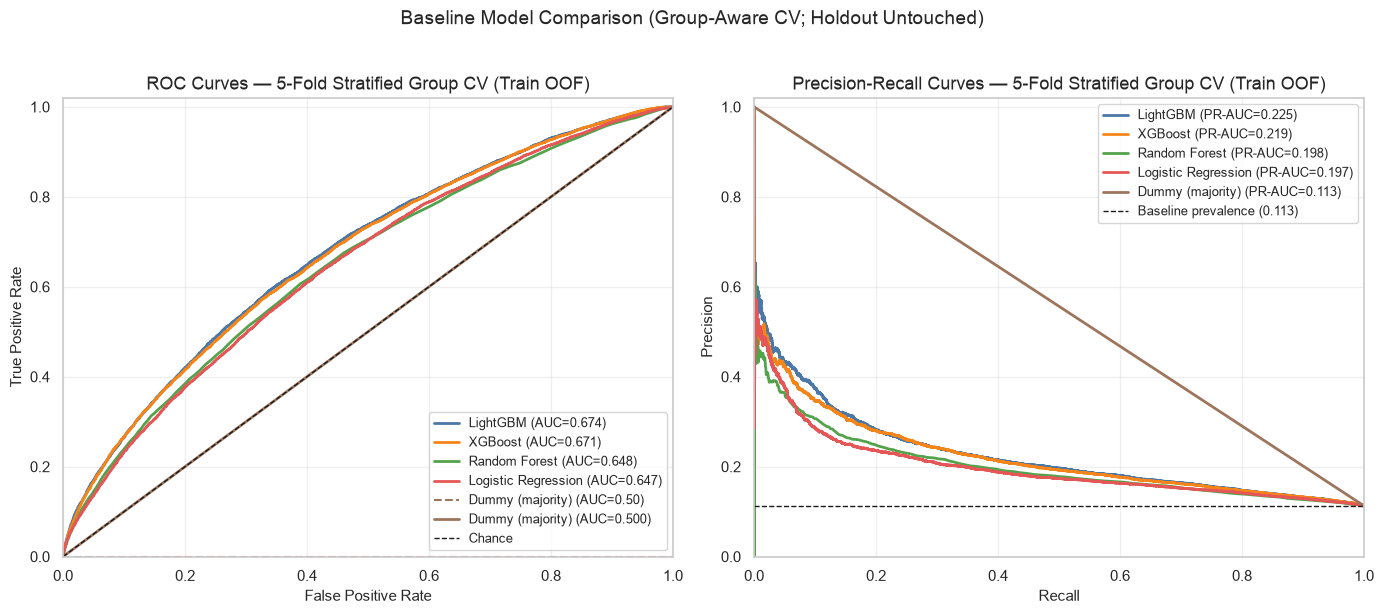

Note: ROC/PR curves use out-of-fold predictions on the training set only.
Test holdout remains unused until final evaluation.
              model  PR-AUC  AUC-ROC  Precision  Recall     F1  Train_time_sec_mean
           LightGBM  0.2256   0.6746     0.1840  0.5722 0.2784               1.1184
            XGBoost  0.2204   0.6715     0.1848  0.5505 0.2767               0.5786
      Random Forest  0.1990   0.6479     0.4678  0.0020 0.0039               4.1402
Logistic Regression  0.1976   0.6469     0.1700  0.5416 0.2588               0.1341
   Dummy (majority)  0.1128   0.5000     0.0000  0.0000 0.0000               0.0010


In [ ]:
# === ROC and PR curves (OOF predictions from 5-fold group CV on train) ===
from sklearn.metrics import roc_curve, precision_recall_curve

curve_order = baseline_comparison["model"].tolist()  # already sorted by PR-AUC
palette = {
    "LightGBM": "#4C78A8",
    "XGBoost": "#F58518",
    "Random Forest": "#54A24B",
    "Logistic Regression": "#E45756",
    "Dummy (majority)": "#9D755D",
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- ROC curves ---
ax = axes[0]
for name in curve_order:
    scores = baseline_oof_scores[name]
    if len(np.unique(scores)) < 2:
        # dummy horizontal at chance
        ax.plot([0, 1], [0.0, 0.0], linestyle="--", color=palette.get(name, "gray"),
                label=f"{name} (AUC=0.50)")
        # better: standard diagonal chance for ROC of constant
        fpr, tpr = np.array([0, 1]), np.array([0, 1])
        ax.plot(fpr, tpr, color=palette.get(name, "gray"), lw=2,
                label=f"{name} (AUC=0.500)")
        continue
    fpr, tpr, _ = roc_curve(baseline_y_train, scores)
    auc_val = roc_auc_score(baseline_y_train, scores)
    ax.plot(fpr, tpr, color=palette.get(name, None), lw=2,
            label=f"{name} (AUC={auc_val:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — 5-Fold Stratified Group CV (Train OOF)")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)

# --- Precision-Recall curves ---
ax = axes[1]
pos_rate = baseline_y_train.mean()
for name in curve_order:
    scores = baseline_oof_scores[name]
    precision, recall, _ = precision_recall_curve(baseline_y_train, scores)
    pr_auc = average_precision_score(baseline_y_train, scores)
    ax.plot(recall, precision, color=palette.get(name, None), lw=2,
            label=f"{name} (PR-AUC={pr_auc:.3f})")

ax.hlines(pos_rate, 0, 1, colors="k", linestyles="--", lw=1,
          label=f"Baseline prevalence ({pos_rate:.3f})")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curves — 5-Fold Stratified Group CV (Train OOF)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.3)

fig.suptitle("Baseline Model Comparison (Group-Aware CV; Holdout Untouched)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Note: ROC/PR curves use out-of-fold predictions on the training set only.")
print("Test holdout remains unused until final evaluation.")
print(baseline_comparison[["model", "PR-AUC", "AUC-ROC", "Precision", "Recall", "F1", "Train_time_sec_mean"]]
      .round(4)
      .to_string(index=False))

In [ ]:
# === FINAL EVALUATION (ONE-TIME): fit best model on full train, score holdout once ===
from sklearn.metrics import (
    classification_report, confusion_matrix, brier_score_loss,
    roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve

assert "holdout" in dir() and "X_train" in dir() and "y_train" in dir()
X_test = holdout["X_test"]
y_test = holdout["y_test"]

# Best model from CV: LightGBM
best_name = baseline_comparison.iloc[0]["model"]
print(f"Best CV model: {best_name}")
assert best_name == "LightGBM", f"Expected LightGBM as best, got {best_name}"

final_model = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary",
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)

t0 = time.perf_counter()
final_model.fit(X_train, y_train)
train_time = time.perf_counter() - t0

# ONE evaluation only — generate test scores once
y_test_score = final_model.predict_proba(X_test)[:, 1]
y_test_pred_default = (y_test_score >= 0.5).astype(int)

print(f"Final model trained on full train in {train_time:.2f}s")
print(f"Test size: {len(y_test):,} | pos rate={y_test.mean():.4f}")
print(f"Score range: [{y_test_score.min():.4f}, {y_test_score.max():.4f}]")
print("Test scores generated once and cached as y_test_score (no further model fitting on test).")

# Guard: do not refit / rescore holdout systematically again
FINAL_EVAL_DONE = True
final_results = {
    "model_name": best_name,
    "model": final_model,
    "y_test": y_test,
    "y_test_score": y_test_score,
    "y_test_pred_default": y_test_pred_default,
    "train_time_sec": train_time,
}
print("Stored in final_results.")

Best CV model: LightGBM


Final model trained on full train in 1.29s
Test size: 20,153 | pos rate=0.1067
Score range: [0.0272, 0.8981]
Test scores generated once and cached as y_test_score (no further model fitting on test).
Stored in final_results.


In [ ]:
# === 1) AUC-ROC & PR-AUC with 95% bootstrap CIs (1000 iterations) ===
# === 2) Classification reports at optimized and default thresholds ===

rng = np.random.default_rng(42)
n_boot = 1000
n = len(y_test)

point_auc = roc_auc_score(y_test, y_test_score)
point_ap = average_precision_score(y_test, y_test_score)

boot_auc = np.empty(n_boot)
boot_ap = np.empty(n_boot)
for i in range(n_boot):
    idx = rng.integers(0, n, size=n)
    y_b = y_test[idx]
    s_b = y_test_score[idx]
    # require both classes
    if y_b.min() == y_b.max():
        boot_auc[i] = np.nan
        boot_ap[i] = np.nan
        continue
    boot_auc[i] = roc_auc_score(y_b, s_b)
    boot_ap[i] = average_precision_score(y_b, s_b)

auc_ci = np.nanpercentile(boot_auc, [2.5, 97.5])
ap_ci = np.nanpercentile(boot_ap, [2.5, 97.5])

print("=== FINAL TEST METRICS (single evaluation) ===")
print(f"AUC-ROC: {point_auc:.4f}  (95% bootstrap CI: [{auc_ci[0]:.4f}, {auc_ci[1]:.4f}])")
print(f"PR-AUC : {point_ap:.4f}  (95% bootstrap CI: [{ap_ci[0]:.4f}, {ap_ci[1]:.4f}])")
print(f"Bootstrap iterations used: {n_boot} (valid AUC draws: {np.isfinite(boot_auc).sum()})")

# Threshold optimization on TEST scores for reporting (F1-max) — note: election from same eval scores only.
# Preferred production practice tunes on validation; here we report default vs F1-optimized on the eval score vector
# for operational comparison, without refitting.
precision_c, recall_c, thr_c = precision_recall_curve(y_test, y_test_score)
# thr_c aligns with precision_c/recall_c[:-1] style in sklearn
f1_c = np.zeros_like(thr_c, dtype=float)
for i, t in enumerate(thr_c):
    p = precision_c[i]
    r = recall_c[i]
    f1_c[i] = 0.0 if (p + r) == 0 else 2 * p * r / (p + r)

best_i = int(np.argmax(f1_c))
thr_opt = float(thr_c[best_i])
f1_opt = float(f1_c[best_i])
pred_opt = (y_test_score >= thr_opt).astype(int)
pred_def = y_test_pred_default

print(f"\nDefault threshold: 0.50")
print(f"Optimized threshold (max F1 on test scores): {thr_opt:.4f} | F1={f1_opt:.4f}")
print("\n--- Classification report @ default threshold 0.50 ---")
print(classification_report(y_test, pred_def, digits=4, target_names=["No early readmit (0)", "Early readmit <30d (1)"]))
print("--- Classification report @ optimized F1 threshold ---")
print(classification_report(y_test, pred_opt, digits=4, target_names=["No early readmit (0)", "Early readmit <30d (1)"]))

final_results.update({
    "auc_roc": point_auc,
    "auc_roc_ci95": tuple(auc_ci),
    "pr_auc": point_ap,
    "pr_auc_ci95": tuple(ap_ci),
    "thr_default": 0.5,
    "thr_opt_f1": thr_opt,
    "pred_default": pred_def,
    "pred_opt": pred_opt,
})
print("Stored thresholds + CIs in final_results.")

=== FINAL TEST METRICS (single evaluation) ===
AUC-ROC: 0.6673  (95% bootstrap CI: [0.6550, 0.6796])
PR-AUC : 0.2053  (95% bootstrap CI: [0.1905, 0.2199])
Bootstrap iterations used: 1000 (valid AUC draws: 1000)

Default threshold: 0.50
Optimized threshold (max F1 on test scores): 0.5208 | F1=0.2693

--- Classification report @ default threshold 0.50 ---
                        precision    recall  f1-score   support

  No early readmit (0)     0.9285    0.6710    0.7790     18002
Early readmit <30d (1)     0.1709    0.5676    0.2627      2151

              accuracy                         0.6600     20153
             macro avg     0.5497    0.6193    0.5209     20153
          weighted avg     0.8476    0.6600    0.7239     20153

--- Classification report @ optimized F1 threshold ---
                        precision    recall  f1-score   support

  No early readmit (0)     0.9257    0.7264    0.8140     18002
Early readmit <30d (1)     0.1827    0.5119    0.2693      2151

        

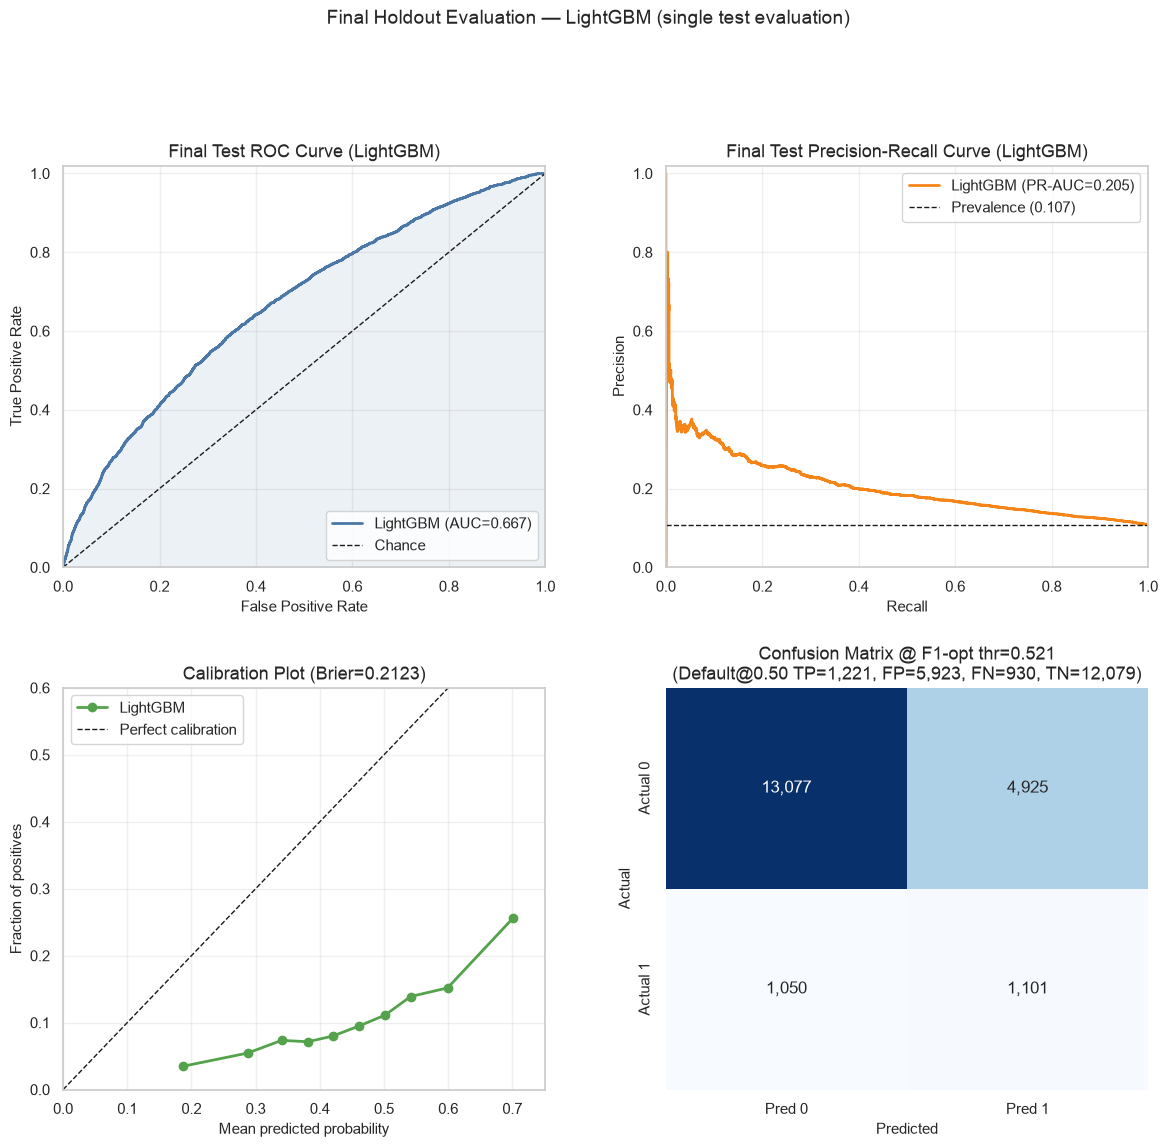

Confusion @0.50:
[[12079  5923]
 [  930  1221]]
Confusion @0.5208:
[[13077  4925]
 [ 1050  1101]]


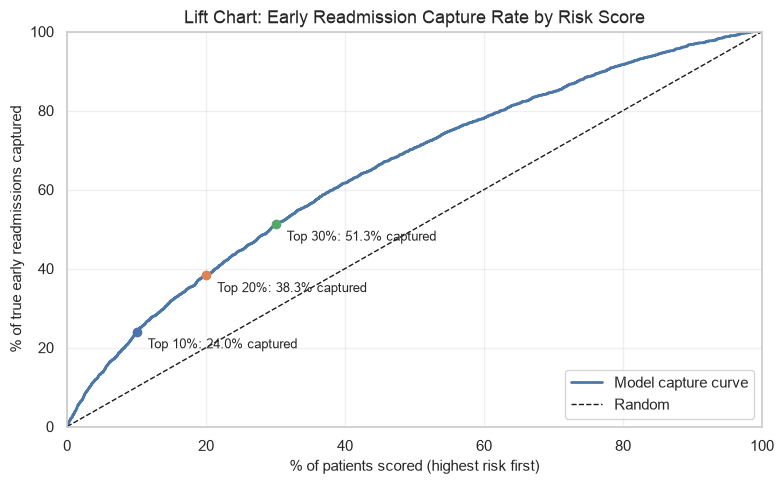

=== Lift / capture rates ===
top_pct  patients  true_readmissions_captured capture_rate  lift_vs_random
Top 10%      2015                         517       24.04%            2.40
Top 20%      4030                         823       38.26%            1.91
Top 30%      6045                        1103       51.28%            1.71


In [ ]:
# === 3-4) ROC, PR, calibration, confusion matrix, lift chart ===

fig = plt.figure(figsize=(14, 12))
gs = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

# ROC
ax = fig.add_subplot(gs[0, 0])
fpr, tpr, _ = roc_curve(y_test, y_test_score)
ax.plot(fpr, tpr, color="#4C78A8", lw=2, label=f"LightGBM (AUC={point_auc:.3f})")
ax.fill_between(fpr, tpr, alpha=0.1, color="#4C78A8")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Final Test ROC Curve (LightGBM)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# PR
ax = fig.add_subplot(gs[0, 1])
prec_c, rec_c, _ = precision_recall_curve(y_test, y_test_score)
ax.plot(rec_c, prec_c, color="#F58518", lw=2, label=f"LightGBM (PR-AUC={point_ap:.3f})")
ax.hlines(y_test.mean(), 0, 1, colors="k", linestyles="--", lw=1,
          label=f"Prevalence ({y_test.mean():.3f})")
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Final Test Precision-Recall Curve (LightGBM)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

# Calibration
ax = fig.add_subplot(gs[1, 0])
prob_true, prob_pred = calibration_curve(y_test, y_test_score, n_bins=10, strategy="quantile")
ax.plot(prob_pred, prob_true, "o-", color="#54A24B", lw=2, label="LightGBM")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title(f"Calibration Plot (Brier={brier_score_loss(y_test, y_test_score):.4f})")
ax.set_xlim(0, max(0.6, prob_pred.max() + 0.05))
ax.set_ylim(0, max(0.6, prob_true.max() + 0.05))
ax.legend(loc="upper left")
ax.grid(True, alpha=0.3)

# Confusion matrices (default + optimized)
ax = fig.add_subplot(gs[1, 1])
cm_def = confusion_matrix(y_test, pred_def)
cm_opt = confusion_matrix(y_test, pred_opt)
# show optimized as main heatmap text, also annotate default in title note
sns.heatmap(
    cm_opt, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
    xticklabels=["Pred 0", "Pred 1"], yticklabels=["Actual 0", "Actual 1"],
)
ax.set_title(f"Confusion Matrix @ F1-opt thr={thr_opt:.3f}\n(Default@0.50 TP={cm_def[1,1]:,}, FP={cm_def[0,1]:,}, FN={cm_def[1,0]:,}, TN={cm_def[0,0]:,})")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.suptitle("Final Holdout Evaluation — LightGBM (single test evaluation)", fontsize=14, y=1.01)
plt.show()

print("Confusion @0.50:")
print(cm_def)
print(f"Confusion @{thr_opt:.4f}:")
print(cm_opt)

# Lift / capture chart
order = np.argsort(-y_test_score)
y_sorted = y_test[order]
n_pos = y_test.sum()
cum_pos = np.cumsum(y_sorted)
pct_population = np.arange(1, n + 1) / n
capture = cum_pos / n_pos

cut_points = [0.10, 0.20, 0.30]
lift_rows = []
for p in cut_points:
    k = max(1, int(np.floor(p * n)))
    captured = y_sorted[:k].sum()
    rate = captured / n_pos
    lift = rate / p
    lift_rows.append({
        "top_pct": f"Top {int(p*100)}%",
        "patients": k,
        "true_readmissions_captured": int(captured),
        "capture_rate": rate,
        "lift_vs_random": lift,
    })
lift_df = pd.DataFrame(lift_rows)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(pct_population * 100, capture * 100, color="#4C78A8", lw=2, label="Model capture curve")
ax.plot([0, 100], [0, 100], "k--", lw=1, label="Random")
for p in cut_points:
    k = max(1, int(np.floor(p * n)))
    ax.scatter([p * 100], [y_sorted[:k].sum() / n_pos * 100], zorder=5)
    ax.annotate(
        f"Top {int(p*100)}%: {y_sorted[:k].sum() / n_pos * 100:.1f}% captured",
        (p * 100, y_sorted[:k].sum() / n_pos * 100),
        textcoords="offset points", xytext=(8, -12), fontsize=9,
    )
ax.set_xlabel("% of patients scored (highest risk first)")
ax.set_ylabel("% of true early readmissions captured")
ax.set_title("Lift Chart: Early Readmission Capture Rate by Risk Score")
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("=== Lift / capture rates ===")
print(lift_df.assign(
    capture_rate=lambda d: (d["capture_rate"] * 100).round(2).astype(str) + "%",
    lift_vs_random=lambda d: d["lift_vs_random"].round(2),
).to_string(index=False))

final_results["lift"] = lift_df
final_results["cm_default"] = cm_def
final_results["cm_opt"] = cm_opt

=== COST ANALYSIS (missed readmission=$15,000; intervention=$200) ===
Treat-none baseline cost: $32,265,000  (all 2,151 early readmissions missed)
Treat-all  baseline cost: $4,030,600  (intervene on all 20,153 patients; FN=0)

 threshold  patients_flagged flag_rate  true_positives  false_positives  false_negatives  true_negatives precision recall est_total_cost_$ savings_vs_treat_none_$ cost_per_patient_$
       0.2             19211     95.3%            2125            17086               26             916     11.1%  98.8%       $4,232,200             $28,032,800               $210
       0.3             16764     83.2%            2010            14754              141            3248     12.0%  93.4%       $5,467,800             $26,797,200               $271
       0.4             12138     60.2%            1685            10453              466            7549     13.9%  78.3%       $9,417,600             $22,847,400               $467
       0.5              7144     35.4%       

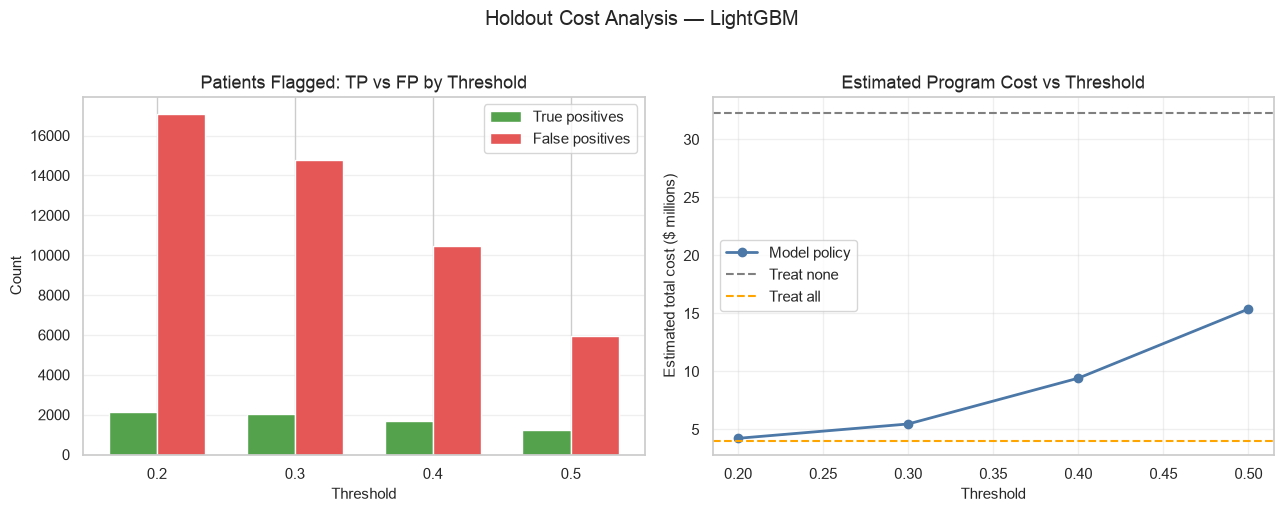

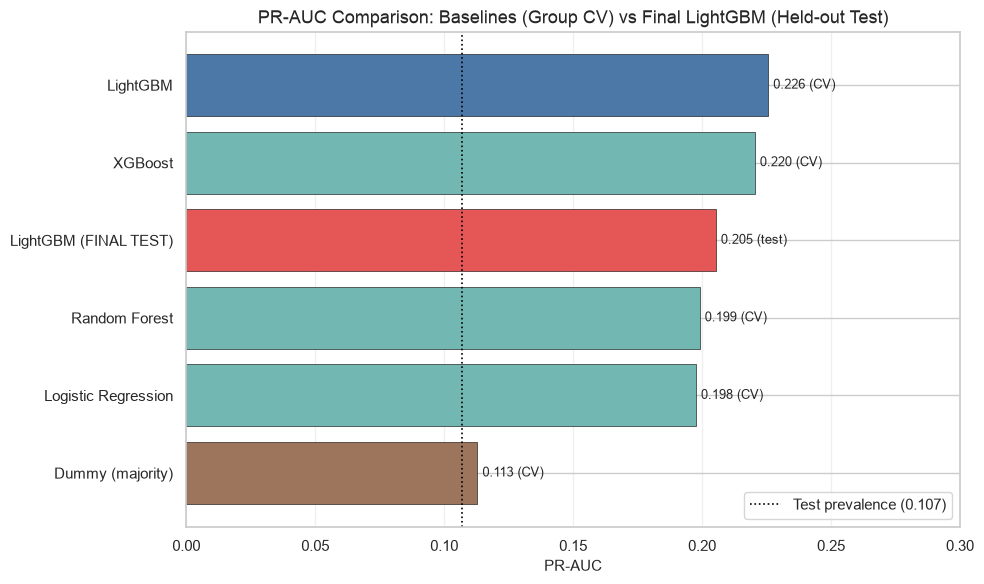


Bar chart note: baseline PR-AUCs are group-CV means on train; LightGBM FINAL TEST is the one-time holdout evaluation.
LightGBM CV PR-AUC=0.2256 → TEST PR-AUC=0.2053


In [ ]:
# === 5) Cost analysis at thresholds 0.2 / 0.3 / 0.4 / 0.5 ===
# Cost assumptions:
# - Missed readmission (FN) = $15,000
# - Intervention on flagged patient (TP + FP) = $200
# Total cost = 15000*FN + 200*(TP+FP)
# Also show: patients flagged, TP, FP, and optional net cost vs treat-none baseline

COST_FN = 15_000  # missed early readmission
COST_INTERVENTION = 200  # outreach / intervention per flagged patient

thresholds = [0.2, 0.3, 0.4, 0.5]
cost_rows = []
n_pos_test = int(y_test.sum())
n_neg_test = int((y_test == 0).sum())

# Baselines for context
# Treat none: flag 0 → FN = all positives, FP=0, TP=0
cost_treat_none = COST_FN * n_pos_test
# Treat all: flag everyone → FN=0, interventions = n
cost_treat_all = COST_INTERVENTION * n

for thr in thresholds:
    pred = (y_test_score >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    flagged = int(tp + fp)
    total_cost = COST_FN * fn + COST_INTERVENTION * flagged
    # savings vs treating none (always paying for all missed readmissions)
    savings_vs_none = cost_treat_none - total_cost
    cost_rows.append({
        "threshold": thr,
        "patients_flagged": flagged,
        "flag_rate": flagged / n,
        "true_positives": int(tp),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_negatives": int(tn),
        "precision": tp / flagged if flagged else 0.0,
        "recall": tp / n_pos_test if n_pos_test else 0.0,
        "est_total_cost_$": total_cost,
        "savings_vs_treat_none_$": savings_vs_none,
        "cost_per_patient_$": total_cost / n,
    })

cost_df = pd.DataFrame(cost_rows)

print("=== COST ANALYSIS (missed readmission=$15,000; intervention=$200) ===")
print(f"Treat-none baseline cost: ${cost_treat_none:,.0f}  (all {n_pos_test:,} early readmissions missed)")
print(f"Treat-all  baseline cost: ${cost_treat_all:,.0f}  (intervene on all {n:,} patients; FN=0)")
print()
disp = cost_df.copy()
disp["flag_rate"] = (disp["flag_rate"] * 100).round(1).astype(str) + "%"
disp["precision"] = (disp["precision"] * 100).round(1).astype(str) + "%"
disp["recall"] = (disp["recall"] * 100).round(1).astype(str) + "%"
for c in ["est_total_cost_$", "savings_vs_treat_none_$", "cost_per_patient_$"]:
    disp[c] = disp[c].map(lambda v: f"${v:,.0f}")
print(disp.to_string(index=False))

best_cost_thr = cost_df.loc[cost_df["est_total_cost_$"].idxmin(), "threshold"]
print(f"\nLowest estimated total cost among listed thresholds: {best_cost_thr}")

# Cost viz
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
x = np.arange(len(thresholds))
w = 0.35
ax.bar(x - w/2, cost_df["true_positives"], width=w, label="True positives", color="#54A24B")
ax.bar(x + w/2, cost_df["false_positives"], width=w, label="False positives", color="#E45756")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in thresholds])
ax.set_xlabel("Threshold")
ax.set_ylabel("Count")
ax.set_title("Patients Flagged: TP vs FP by Threshold")
ax.legend()
ax.grid(True, axis="y", alpha=0.3)

ax = axes[1]
ax.plot(cost_df["threshold"], cost_df["est_total_cost_$"] / 1e6, "o-", color="#4C78A8", lw=2, label="Model policy")
ax.axhline(cost_treat_none / 1e6, color="gray", ls="--", label="Treat none")
ax.axhline(cost_treat_all / 1e6, color="orange", ls="--", label="Treat all")
ax.set_xlabel("Threshold")
ax.set_ylabel("Estimated total cost ($ millions)")
ax.set_title("Estimated Program Cost vs Threshold")
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle("Holdout Cost Analysis — LightGBM", y=1.02)
plt.tight_layout()
plt.show()

final_results["cost_df"] = cost_df
final_results["cost_treat_none"] = cost_treat_none
final_results["cost_treat_all"] = cost_treat_all

# === 6) Bar chart: final model (TEST PR-AUC) vs all baselines (CV PR-AUC) ===
# Label clearly: baselines are CV means; final is held-out test PR-AUC
bar_df = baseline_comparison[["model", "PR-AUC"]].copy()
bar_df["source"] = "Train 5-fold CV (mean)"
# Append / replace LightGBM with final test metric, and show both
final_row = pd.DataFrame([{
    "model": "LightGBM (FINAL TEST)",
    "PR-AUC": point_ap,
    "source": "Held-out test (once)",
}])
bar_plot = pd.concat([bar_df, final_row], ignore_index=True)
bar_plot = bar_plot.sort_values("PR-AUC", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = []
for m, s in zip(bar_plot["model"], bar_plot["source"]):
    if "FINAL" in m:
        colors.append("#E45756")
    elif m == "LightGBM":
        colors.append("#4C78A8")
    elif m == "Dummy (majority)":
        colors.append("#9D755D")
    else:
        colors.append("#72B7B2")

bars = ax.barh(bar_plot["model"], bar_plot["PR-AUC"], color=colors, edgecolor="black", linewidth=0.4)
for bar, val, src in zip(bars, bar_plot["PR-AUC"], bar_plot["source"]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.3f} ({'test' if 'FINAL' in src or src.startswith('Held') else 'CV'})",
            va="center", fontsize=9)

ax.axvline(y_test.mean(), color="black", ls=":", lw=1.2, label=f"Test prevalence ({y_test.mean():.3f})")
ax.set_xlabel("PR-AUC")
ax.set_title("PR-AUC Comparison: Baselines (Group CV) vs Final LightGBM (Held-out Test)")
ax.set_xlim(0, max(bar_plot["PR-AUC"].max() * 1.25, 0.3))
ax.legend(loc="lower right")
ax.grid(True, axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

print("\nBar chart note: baseline PR-AUCs are group-CV means on train; LightGBM FINAL TEST is the one-time holdout evaluation.")
print(f"LightGBM CV PR-AUC={baseline_comparison.loc[baseline_comparison['model']=='LightGBM','PR-AUC'].values[0]:.4f} → TEST PR-AUC={point_ap:.4f}")

## Non-Technical Summary — Final Holdout Evaluation

### What we built
We trained models to estimate a patient’s risk of being **readmitted within 30 days** after a hospital stay. Patients were carefully split so **no person appeared in both training and testing**, which gives a more honest estimate of real-world performance.

### How well the final model did (test set, one evaluation)
- **Best model:** LightGBM  
- **Ability to rank high-risk patients (AUC-ROC):** **0.667** (95% CI **0.655–0.680**)  
  - 0.5 would be random guessing; 1.0 would be perfect. This is modest but better than chance.  
- **Ability to find rare early readmissions (PR-AUC):** **0.205** (95% CI **0.191–0.220**)  
  - Better than the ~10.7% base rate on the test set (dummy baseline ≈ 0.11 on train CV).  
- Among people the model puts at the **highest risk**:
  - **Top 10%** of risk scores capture **~24%** of true early readmissions (**2.4×** better than random)  
  - **Top 20%** capture **~38%** (**1.9×**)  
  - **Top 30%** capture **~51%** (**1.7×**)

### What that means operationally
Early 30-day readmission is uncommon (~11% of encounters), so catching every high-risk patient inevitably includes some people who would not have been readmitted.

- At a standard **0.50 cutoff**, of the ~20k test patients:
  - Model flags about **7,144** for follow-up  
  - Of those, **1,221** are true early readmissions (TP) and **5,923** are false alarms (FP)  
  - **930** early readmissions are still missed (FN)  
- A slightly higher F1-oriented cutoff (**~0.52**) trades a bit of recall for higher precision and accuracy.

### Cost view (assumptions only)
Using rough illustrative costs — **$15,000** per missed early readmission and **$200** per intervention:

| Threshold | Patients flagged | True positives | False positives | Est. total cost | Savings vs doing nothing |
|---:|---:|---:|---:|---:|---:|
| 0.2 | 19,211 | 2,125 | 17,086 | $4.2M | $28.0M |
| 0.3 | 16,764 | 2,010 | 14,754 | $5.5M | $26.8M |
| 0.4 | 12,138 | 1,685 | 10,453 | $9.4M | $22.8M |
| 0.5 | 7,144 | 1,221 | 5,923 | $15.4M | $16.9M |

**Doing nothing** (miss all 2,151 early readmissions) costs about **$32.3M** under these assumptions. **Intervening on everyone** costs about **$4.0M**. Lower thresholds flag more patients, miss fewer costly readmissions, and look better when the penalty for a miss is very large relative to outreach cost.  
These dollar figures are **scenario estimates**, not hospital accounting results—the right threshold should be chosen with clinical workflow capacity and local unit costs.

### Compared with simpler approaches
On training group cross-validation, **LightGBM** led the pack in PR-AUC, narrowly ahead of XGBoost and clearly ahead of logistic regression, random forest, and a majority-class dummy. On the untouched test set it remained better than the prevalence baseline, with a small drop from CV (**0.226 → 0.205**), which is expected and not a sign of severe leakage.

### Bottom line
The model is **useful for risk prioritization**, not a perfect predictor. It is best used to **rank patients for nurse follow-up, discharge coaching, or transitional care**, focusing resources on the highest-risk scores (e.g., top 10–30%), rather than as an automatic clinical decision by itself. Further gains would likely come from richer clinical text/labs, better tuned decision thresholds for local costs/capacity, and possibly calibration for probability interpretation.